<a href="https://colab.research.google.com/github/JHastings46/HoopsValuePro/blob/main/Free_Agent_Surplus_Value_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NBA Free Agent Value Board: Predicting Contract Efficiency and Future Production

## Overview
This project develops a predictive model to assess the fair market value of NBA free agents and project their future on-court production (VORP) for the 2026 free agency class. The goal is to provide a data-driven tool for General Managers (GMs) to identify potentially overpaid or underpaid players and optimize roster construction.

In [1]:
from google.colab import drive
import os
import shutil # For rmtree

mount_point = '/content/drive'

# Attempt to unmount first if it's currently mounted
if os.path.ismount(mount_point):
    print("Google Drive is already mounted. Attempting to flush and unmount for a cleaner remount.")
    try:
        drive.flush_and_unmount()
        print("Google Drive unmounted successfully.")
    except Exception as e:
        print(f"Failed to unmount Google Drive: {e}. Proceeding with attempt to clear directory contents.")

# Now, regardless of whether it was mounted or unmounted, ensure the directory is empty
if os.path.isdir(mount_point):
    if len(os.listdir(mount_point)) > 0:
        print(f"Mountpoint {mount_point} is not empty. Attempting to clear its contents.")
        try:
            # Remove all contents (files and subdirectories)
            for item in os.listdir(mount_point):
                item_path = os.path.join(mount_point, item)
                if os.path.isfile(item_path) or os.path.islink(item_path):
                    os.unlink(item_path)
                elif os.path.isdir(item_path):
                    shutil.rmtree(item_path)
            print(f"Contents of {mount_point} cleared successfully.")
        except Exception as e:
            print(f"Error clearing contents of {mount_point}: {e}. This might prevent successful mounting.")
    else:
        print(f"Mountpoint {mount_point} is already empty.")
else:
    # If the directory doesn't exist, create it. drive.mount will also create it, but this pre-empts.
    print(f"Mountpoint {mount_point} does not exist. Creating directory.")
    os.makedirs(mount_point)

# Finally, attempt to mount
print("Attempting to mount Google Drive...")
drive.mount(mount_point, force_remount=True)

Mountpoint /content/drive does not exist. Creating directory.
Attempting to mount Google Drive...
Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn as sns #used to make statistcal data visualizations with numbers
import sklearn
import xgboost as xgb
import shap
import time # mesures how long the code will tak


# In Google Colab, use pip instead of conda
!pip install -q lxml


# Load Basketball Reference advanced stats tables

url_2022 = "https://www.basketball-reference.com/leagues/NBA_2022_advanced.html"
url_2023 = "https://www.basketball-reference.com/leagues/NBA_2023_advanced.html"
url_2024 = "https://www.basketball-reference.com/leagues/NBA_2024_advanced.html"
url_2025 = "https://www.basketball-reference.com/leagues/NBA_2025_advanced.html"
url_2026 = "https://www.basketball-reference.com/leagues/NBA_2026_advanced.html"


tables_2022 = pd.read_html(url_2022)
tables_2023 = pd.read_html(url_2023)
tables_2024 = pd.read_html(url_2024)
tables_2025 = pd.read_html(url_2025)
tables_2026 = pd.read_html(url_2026)


adv_2022 = tables_2022[0]
adv_2023 = tables_2023[0]
adv_2024 = tables_2024[0]
adv_2025 = tables_2025[0]
adv_2026 = tables_2026[0]

# Check results
print("2022:", adv_2022.shape)
print("2023:", adv_2023.shape)
print("2024:", adv_2024.shape)
print("2025:", adv_2025.shape)
print("2026:", adv_2026.shape)

adv_2026.head()

2022: (813, 29)
2023: (680, 29)
2024: (736, 29)
2025: (736, 29)
2026: (734, 29)


,Rk,Player,Age,Team,Pos,G,GS,MP,PER,TS%,...,USG%,OWS,DWS,WS,WS/48,OBPM,DBPM,BPM,VORP,Awards
0,1.0,Amen Thompson,23.0,HOU,PG,79.0,79.0,2953.0,18.9,0.594,...,20.0,6.5,3.8,10.3,0.167,1.6,1.0,2.6,3.4,DPOY-8
1,2.0,Kevin Durant,37.0,HOU,SF,78.0,78.0,2840.0,21.1,0.641,...,27.1,7.5,3.2,10.7,0.180,4.4,0.1,4.5,4.7,"CPOY-9,AS,NBA2"
2,3.0,Desmond Bane,27.0,ORL,SG,82.0,82.0,2756.0,16.9,0.607,...,23.3,4.8,2.6,7.4,0.129,1.6,-0.2,1.4,2.3,NaN
3,4.0,Toumani Camara,25.0,POR,PF,82.0,82.0,2731.0,11.3,0.578,...,16.3,2.1,2.7,4.8,0.084,-1.0,0.0,-1.0,0.7,NaN
4,5.0,Jabari Smith Jr.,22.0,HOU,PF,77.0,77.0,2705.0,13.5,0.570,...,18.2,3.4,3.3,6.6,0.118,-0.5,-0.2,-0.7,0.9,NaN


In [3]:

# rename columns
rename_cols = {
    "Player": "player_name",
    "Age": "age",
    "Team": "team",
    "MP": "mp",
    "PER": "per",
    "OWS": "ows",
    "DWS": "dws",
    "WS": "ws",
    "VORP": "vorp",
    "ORB%": "orb_pct",
    "DRB%": "drb_pct",
    "TRB%": "trb_pct",
    "WS/48": "ws_48",
    "OBPM": "obpm",
    "DBPM": "dbpm",
    "BPM": "bpm",
    "TS%": "ts_pct",
    "AST%": "ast_pct",
    "TOV%": "tov_pct",
    "USG%": "usg_pct",
    "STL%": "stl_pct",
    "BLK%": "blk_pct",
    "3PAr": "3par",
    "FTr": "ftr"
}


adv_2022 = adv_2022.rename(columns=rename_cols)
adv_2023 = adv_2023.rename(columns=rename_cols)
adv_2024 = adv_2024.rename(columns=rename_cols)
adv_2025 = adv_2025.rename(columns=rename_cols)
adv_2026 = adv_2026.rename(columns=rename_cols)

# Add season labels
adv_2022['season'] = 2022
adv_2023['season'] = 2023
adv_2024['season'] = 2024
adv_2025['season'] = 2025
adv_2026['season'] = 2026

def keep_combined_player_rows(df):
    return (
        df.assign(_multi=df["team"].astype(str).str.contains("TM", na=False))
          .sort_values(["player_name", "_multi"], ascending=[True, False])
          .drop_duplicates(subset=["player_name"], keep="first")
          .drop(columns=["_multi"])
          .reset_index(drop=True)
    )


# Apply to every season
adv_2022 = keep_combined_player_rows(adv_2022)
adv_2023 = keep_combined_player_rows(adv_2023)
adv_2024 = keep_combined_player_rows(adv_2024)
adv_2025 = keep_combined_player_rows(adv_2025)
adv_2026 = keep_combined_player_rows(adv_2026)



# Create the correct three-year windows
adv_window_2024 = pd.concat(
    [
        adv_2022,
        adv_2023,
        adv_2024
    ],
    ignore_index=True
)

adv_window_2025 = pd.concat(
    [
        adv_2023,
        adv_2024,
        adv_2025
    ],
    ignore_index=True
)

adv_window_2026 = pd.concat(
    [
        adv_2024,
        adv_2025,
        adv_2026
    ],
    ignore_index=True
)

In [4]:
# List the advanced stats to weight by minutes
weighted_features = [
    "per",
    "ows",
    "dws",
    "ws",
    "vorp",
    "orb_pct",
    "drb_pct",
    "trb_pct",
    "ws_48",
    "obpm",
    "dbpm",
    "bpm",
    "ts_pct",
    "ast_pct",
    "tov_pct",
    "usg_pct",
    "stl_pct",
    "blk_pct",
    "3par",
    "ftr"
]

# Make minutes & Stats numerical
cols_to_numeric = ["mp"] + weighted_features

# Convert columns in each season dataframe
season_dfs = [
    adv_2022,
    adv_2023,
    adv_2024,
    adv_2025,
    adv_2026
]

for df in season_dfs:
    df[cols_to_numeric] = df[cols_to_numeric].apply(
        pd.to_numeric,
        errors="coerce"
    )

In [5]:

# Rate stats: use minutes-weighted averages
rate_features = [
    "per",
    "orb_pct",
    "drb_pct",
    "trb_pct",
    "ws_48",
    "obpm",
    "dbpm",
    "bpm",
    "ts_pct",
    "ast_pct",
    "tov_pct",
    "usg_pct",
    "stl_pct",
    "blk_pct",
    "3par",
    "ftr"
]

# Cumulative stats: add across the three seasons
total_features = [
    "ows",
    "dws",
    "ws",
    "vorp"
]


# Weighted average function
def minute_weighted_avg(group, stat_col):
    valid = group.dropna(subset=[stat_col, "mp"])

    if valid["mp"].sum() == 0:
        return np.nan

    return (
        (valid[stat_col] * valid["mp"]).sum()
        / valid["mp"].sum()
    )


# Create one three-year player profile table
def create_weighted_stats(window_df):
    player_rows = []

    for player_name, group in window_df.groupby("player_name"):
        player_row = {
            "player_name": player_name,
            "seasons_available": group["season"].nunique(),
            "total_mp_3yr": group["mp"].sum(),
            "age": group.loc[group["season"].idxmax(), "age"]
        }

        # Minutes-weighted rate statistics
        for stat in rate_features:
            player_row[f"{stat}_weighted"] = (
                minute_weighted_avg(group, stat)
            )

        # Three-year cumulative statistics
        for stat in total_features:
            player_row[f"{stat}_3yr_total"] = (
                group[stat].sum(min_count=1)
            )

        player_rows.append(player_row)

    return pd.DataFrame(player_rows)


# Calculate each rolling three-year window
weighted_2024 = create_weighted_stats(adv_window_2024)
weighted_2025 = create_weighted_stats(adv_window_2025)
weighted_2026 = create_weighted_stats(adv_window_2026)


# Label the free-agent class each profile belongs to

weighted_2024["free_agent_yr"] = 2024
weighted_2024["window_start"] = 2022
weighted_2024["window_end"] = 2024

weighted_2025["free_agent_yr"] = 2025
weighted_2025["window_start"] = 2023
weighted_2025["window_end"] = 2025

weighted_2026["free_agent_yr"] = 2026
weighted_2026["window_start"] = 2024
weighted_2026["window_end"] = 2026

# Combine the completed tables
weighted_advanced_stats = pd.concat(
    [
        weighted_2024,
        weighted_2025,
        weighted_2026
    ],
    ignore_index=True
)


# Check results
print("2024 weighted table:", weighted_2024.shape)
print("2025 weighted table:", weighted_2025.shape)
print("2026 weighted table:", weighted_2026.shape)
print("Combined weighted table:", weighted_advanced_stats.shape)

weighted_advanced_stats.head()


2024 weighted table: (819, 27)
2025 weighted table: (772, 27)
2026 weighted table: (803, 27)
Combined weighted table: (2394, 27)


,player_name,seasons_available,total_mp_3yr,age,per_weighted,orb_pct_weighted,drb_pct_weighted,trb_pct_weighted,ws_48_weighted,obpm_weighted,...,blk_pct_weighted,3par_weighted,ftr_weighted,ows_3yr_total,dws_3yr_total,ws_3yr_total,vorp_3yr_total,free_agent_yr,window_start,window_end
0,A.J. Green,2,959.0,24.0,10.859750,1.707925,10.211575,6.095725,0.093713,-0.364025,...,0.384150,0.854086,0.073616,1.2,0.6,1.9,0.1,2024,2022,2024
1,A.J. Lawson,2,419.0,23.0,11.895943,5.286635,13.553699,9.444391,0.042959,-2.687589,...,0.593795,0.452952,0.187938,0.1,0.4,0.3,-0.3,2024,2022,2024
2,AJ Griffin,2,1572.0,20.0,11.359924,2.715076,9.352290,5.967366,0.053788,-0.920038,...,0.743511,0.501555,0.081908,0.9,0.9,1.8,0.1,2024,2022,2024
3,Aaron Gordon,3,6728.0,28.0,17.094961,7.961474,14.499420,11.347518,0.135869,1.319322,...,1.852720,0.245410,0.351986,12.3,6.8,19.1,4.9,2024,2022,2024
4,Aaron Henry,1,17.0,22.0,-7.400000,0.000000,6.500000,3.300000,-0.306000,-14.000000,...,10.600000,0.200000,0.000000,-0.1,0.0,-0.1,-0.1,2024,2022,2024


In [6]:
print(
    "2024 FA profile uses:",
    sorted(adv_window_2024["season"].unique())
)

print(
    "2025 FA profile uses:",
    sorted(adv_window_2025["season"].unique())
)

print(
    "2026 FA profile uses:",
    sorted(adv_window_2026["season"].unique())
)

print("\nWindow mapping:")

display(
    weighted_advanced_stats[
        ["free_agent_yr", "window_start", "window_end"]
    ]
    .drop_duplicates()
    .sort_values("free_agent_yr")
)

print(
    "\nDuplicate player-year rows:",
    weighted_advanced_stats.duplicated(
        ["player_name", "free_agent_yr"]
    ).sum()
)

2024 FA profile uses: [np.int64(2022), np.int64(2023), np.int64(2024)]
2025 FA profile uses: [np.int64(2023), np.int64(2024), np.int64(2025)]
2026 FA profile uses: [np.int64(2024), np.int64(2025), np.int64(2026)]

Window mapping:


,free_agent_yr,window_start,window_end
0,2024,2022,2024
819,2025,2023,2025
1591,2026,2024,2026



Duplicate player-year rows: 0


In [7]:
#Find duplicates How many duplicated rows exist in the df?
duplicate_rows = weighted_advanced_stats.duplicated().sum()
print(f"There are {duplicate_rows} duplicate rows.")

#Finding Missing Values for all columns.
total_missing_values = weighted_advanced_stats.isnull().sum().sum()

print(f"There are {total_missing_values} missing values in total.")
weighted_advanced_stats.shape

There are 0 duplicate rows.
There are 141 missing values in total.


(2394, 27)

In [8]:
# fix names
import unicodedata
import pandas as pd

def fix_name(name):
    if pd.isna(name):
        return name

    name = str(name)
    name = unicodedata.normalize("NFKD", name)
    name = "".join(c for c in name if not unicodedata.combining(c))
    return name.strip()

In [9]:
import pandas as pd

# Load contracts table
nba_fa = pd.read_excel("/content/drive/MyDrive/2026 NBA Free Agents.xlsx")
nba_fa.head()
nba_fa.columns.tolist()

['From',
 'To',
 'Player ',
 'Pos',
 'Yrs',
 'Value                                                                      ',
 'AAV                                                                     ',
 'Total_GTD                                                                      ',
 'Total_GTD_PCT                                                                   ',
 'GTD_ @ _Sign                                                                     ',
 'AAV % Cap',
 'fa_year']

In [10]:


print("Raw Spotrac rows:", len(nba_fa))


Raw Spotrac rows: 390


In [11]:
nba_fa["fa_year"].value_counts(dropna=False).sort_index()

,count
fa_year,
2024,156
2025,128
2026,106


In [12]:
nba_fa.columns = nba_fa.columns.str.replace(r"\s+", " ", regex=True).str.strip()

nba_fa.columns.tolist()

['From',
 'To',
 'Player',
 'Pos',
 'Yrs',
 'Value',
 'AAV',
 'Total_GTD',
 'Total_GTD_PCT',
 'GTD_ @ _Sign',
 'AAV % Cap',
 'fa_year']

In [13]:
nba_fa = nba_fa.rename(columns={
    "From": "team_fa",
    "To": "team_signed_with",
    "Player": "player",
    "Pos": "position",
    "Yrs": "contract_years",
    "Value": "contract_value",
    "AAV": "aav",
    "Total GTD": "total_gtd",
    "Total GTD %": "total_gtd_pct",
    "GTD @ Sign": "gtd_at_sign",
    "AAV % Cap": "aav_pct_cap",
    "fa_year": "free_agent_yr"
})

In [14]:
[col for col in nba_fa.columns if "year" in col.lower() or "fa" in col.lower()]

['team_fa', 'contract_years']

In [15]:
nba_fa = nba_fa[
    [
    "player",
     "free_agent_yr",
      "team_signed_with",
      "position",
      "contract_years",
      "contract_value",
      "aav",
      "aav_pct_cap"
    ]
].copy()

nba_fa.head()

,player,free_agent_yr,team_signed_with,position,contract_years,contract_value,aav,aav_pct_cap
0,Trae Young,2026,WAS,PG,4,212799690,53199923.0,0.3225
1,Austin Reaves,2026,LAL,SG,4,184756320,46189080.0,0.2800
2,Walker Kessler,2026,LAL,C,4,129467930,32366983.0,0.1962
3,Ayo Dosunmu,2026,MIN,PG,5,112000000,22400000.0,0.1358
4,Tari Eason,2026,HOU,PF,5,81449460,16289892.0,0.0987


In [16]:
nba_fa["aav"] = (
   nba_fa["aav"]
    .astype(str) # Explicitly convert to string to ensure .str accessor works
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)



In [17]:
nba_fa.head()

,player,free_agent_yr,team_signed_with,position,contract_years,contract_value,aav,aav_pct_cap
0,Trae Young,2026,WAS,PG,4,212799690,53199923.0,0.3225
1,Austin Reaves,2026,LAL,SG,4,184756320,46189080.0,0.2800
2,Walker Kessler,2026,LAL,C,4,129467930,32366983.0,0.1962
3,Ayo Dosunmu,2026,MIN,PG,5,112000000,22400000.0,0.1358
4,Tari Eason,2026,HOU,PF,5,81449460,16289892.0,0.0987


In [18]:
import pandas as pd
import re
import unicodedata

def clean_player_name(name):
    if pd.isna(name):
        return pd.NA

    # Remove accents
    name = unicodedata.normalize("NFKD", str(name))
    name = name.encode("ascii", "ignore").decode("utf-8")

    # Standardize text
    name = name.lower().strip()

    # Remove suffixes
    name = re.sub(r"\b(jr|sr|ii|iii|iv)\b", "", name)

    # Remove periods, spaces, hyphens, apostrophes, etc.
    name = re.sub(r"[^a-z0-9]", "", name)

    return name

In [19]:
# apply all name fixes before the merge:
name_fixes = {
    "Nicolas Claxton": "Nic Claxton",
    "PJ Washington": "P.J. Washington",
    "AJ Green": "A.J. Green",
    "C.J. McCollum": "CJ McCollum",
    "Robert Williams III": "Robert Williams",
    "Ron Holland II": "Ron Holland",
    "Nah'Shon Hyland": "Bones Hyland",
    "Cameron Thomas": "Cam Thomas",
    "Sviatoslav Mykhailiuk": "Svi Mykhailiuk",
    "Mohamed Bamba": "Mo Bamba"
}

nba_fa["player"] = nba_fa["player"].replace(name_fixes)

In [20]:
nba_fa["player_name_key"] = (
    nba_fa["player"].apply(clean_player_name)
)

weighted_advanced_stats["player_name_key"] = (
    weighted_advanced_stats["player_name"].apply(clean_player_name)
)

In [21]:
# Check which NBA free agents did not match the advanced stats
# Check whether each free agent has the correct player-year profile
name_check = (
    nba_fa[
        ["player", "player_name_key", "free_agent_yr"]
    ]
    .drop_duplicates()
    .merge(
        weighted_advanced_stats[
            ["player_name", "player_name_key", "free_agent_yr"]
        ].drop_duplicates(),
        on=["player_name_key", "free_agent_yr"],
        how="left",
        indicator=True
    )
)


# Show unmatched player-year combinations
unmatched_names = name_check.loc[
    name_check["_merge"] == "left_only",
    ["player", "free_agent_yr"]
]

unmatched_names

,player,free_agent_yr
375,Jeenathan Williams,2024


In [22]:
weighted_advanced_stats.loc[
    weighted_advanced_stats["player_name"]
    .str.contains(
        "Duane|Jeenathan",
        case=False,
        na=False
    ),
    ["player_name"]
]

,player_name
221,Duane Washington Jr.
1023,Duane Washington Jr.


In [23]:
missing_advanced_stats = nba_fa[
    nba_fa["player"].isin([
        "Duane Washington Jr.",
        "Jeenathan Williams"
    ])
].copy()

missing_advanced_stats["exclusion_reason"] = (
    "No matching weighted advanced-stat profile"
)

In [24]:
nba_fa_merged = nba_fa.merge(
    weighted_advanced_stats,
    on=["player_name_key", "free_agent_yr"],
    how="left",
    validate="many_to_one",
    indicator=True,
    suffixes=("_nba_fa", "_advanced")
)


print("Free-agent rows before merge:", len(nba_fa))
print("Rows after merge:", len(nba_fa_merged))

print(
    "Matched rows:",
    (nba_fa_merged["_merge"] == "both").sum()
)

print(
    "Unmatched rows:",
    (nba_fa_merged["_merge"] == "left_only").sum()
)

Free-agent rows before merge: 390
Rows after merge: 390
Matched rows: 389
Unmatched rows: 1


In [25]:
# create the final modeling dataframe

nba_fa_model = nba_fa_merged[
    nba_fa_merged["_merge"] == "both"
].copy()

nba_fa_unmatched = nba_fa_merged[
    nba_fa_merged["_merge"] == "left_only"
].copy()

print("Final modeling rows:", len(nba_fa_model))
print("Excluded unmatched rows:", len(nba_fa_unmatched))

Final modeling rows: 389
Excluded unmatched rows: 1


In [26]:
print(nba_fa_model["_merge"].value_counts())
print("Unmatched rows:", (nba_fa_model["_merge"] == "left_only").sum())

_merge
both          389
left_only       0
right_only      0
Name: count, dtype: int64
Unmatched rows: 0


In [27]:
nba_fa_model = nba_fa_model.drop(columns="_merge")

print(nba_fa_model.shape)

(389, 35)


In [28]:
nba_fa_model.head()

,player,free_agent_yr,team_signed_with,position,contract_years,contract_value,aav,aav_pct_cap,player_name_key,player_name,...,stl_pct_weighted,blk_pct_weighted,3par_weighted,ftr_weighted,ows_3yr_total,dws_3yr_total,ws_3yr_total,vorp_3yr_total,window_start,window_end
0,Trae Young,2026,WAS,PG,4,212799690,53199923.0,0.3225,traeyoung,Trae Young,...,1.676683,0.445923,0.465096,0.417080,9.6,2.1,11.7,4.4,2024.0,2026.0
1,Austin Reaves,2026,LAL,SG,4,184756320,46189080.0,0.2800,austinreaves,Austin Reaves,...,1.448494,0.876156,0.466564,0.362776,13.7,5.5,19.1,6.3,2024.0,2026.0
2,Walker Kessler,2026,LAL,C,4,129467930,32366983.0,0.1962,walkerkessler,Walker Kessler,...,1.050015,8.111603,0.075236,0.328335,6.3,3.6,10.0,3.0,2024.0,2026.0
3,Ayo Dosunmu,2026,MIN,PG,5,112000000,22400000.0,0.1358,ayodosunmu,Ayo Dosunmu,...,1.474594,1.239038,0.400796,0.170077,7.7,3.8,11.5,2.2,2024.0,2026.0
4,Tari Eason,2026,HOU,PF,5,81449460,16289892.0,0.0987,tarieason,Tari Eason,...,2.823050,2.581995,0.373538,0.153031,3.0,6.2,9.2,2.6,2024.0,2026.0


In [29]:
#Data Inspection after JOIN
# data quality check-point

total = len(nba_fa_model)

weighted_matched = nba_fa_model['stl_pct_weighted'].notnull().sum()
fa_matched = nba_fa_model['contract_value'].notnull().sum()

target_matched= nba_fa_model['aav_pct_cap'].notnull().sum()

# valid repeat appearences(Players can only show up multiple times in diff FA years)
dupes = nba_fa_model[['player','free_agent_yr']].duplicated().sum()


print(f"Total player: {total}")
print(f"Weighted stats matched: {weighted_matched}/{total}")
print(f"Free Agent data: {fa_matched}/{total}")
print(f"aav% cap target: {target_matched}/{total}")
print(f"Duplicated player + free agent year rows: {dupes}")


Total player: 389
Weighted stats matched: 389/389
Free Agent data: 389/389
aav% cap target: 387/389
Duplicated player + free agent year rows: 0


In [30]:
# modeling sample prep
weighted_stats_with_target = nba_fa_model[
    nba_fa_model['player_name'].notnull() &
    nba_fa_model['aav_pct_cap'].notnull()
].shape[0]

print(f"Player with both weighted stats and aav% cap target: {weighted_stats_with_target}")

Player with both weighted stats and aav% cap target: 387


In [31]:
# Show the two rows missing the target
missing_target = nba_fa_model[
    nba_fa_model["aav_pct_cap"].isna()
]

missing_target[
    [
        "player",
        "free_agent_yr",
        "team_signed_with",
        "contract_years",
        "contract_value",
        "aav",
        "aav_pct_cap"
    ]
]

,player,free_agent_yr,team_signed_with,contract_years,contract_value,aav,aav_pct_cap
369,Duane Washington Jr.,2024,CHA,0,0,NaN,NaN
372,Justin Minaya,2024,POR,0,0,NaN,NaN


In [32]:
# Keep only rows with a valid target
nba_fa_model = nba_fa_model[
    nba_fa_model["aav_pct_cap"].notna()
].copy()

print("Final modeling rows:", len(nba_fa_model))
print(
    "Missing targets:",
    nba_fa_model["aav_pct_cap"].isna().sum()
)

Final modeling rows: 387
Missing targets: 0


In [33]:
# Required: keep only rows with a valid target
nba_fa_model = nba_fa_model[
    nba_fa_model["aav_pct_cap"].notna()
].copy()

print(f"Final model shape check: {nba_fa_model.shape}")

Final model shape check: (387, 35)


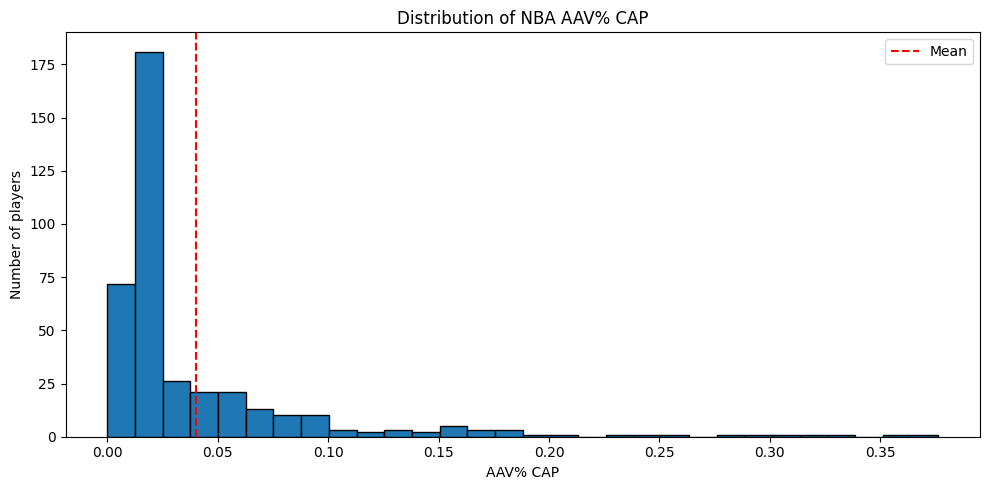

In [34]:
from matplotlib.lines import lineStyles
#EDA-what does the aav% cap look like?
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(nba_fa_model['aav_pct_cap'], bins=30, edgecolor='black')
plt.axvline(nba_fa_model['aav_pct_cap'].mean(), color='red', linestyle= '--',
            label= 'Mean')
plt.xlabel('AAV% CAP')
plt.ylabel('Number of players')
plt.title('Distribution of NBA AAV% CAP')
plt.legend()
plt.tight_layout()
plt.show()




**A right-skewed salary distribution is exactly what we expect in the NBA.**

**Think about the real market**:
- Most free agents sign for relatively small contracts.
- A smaller group signs for mid-level deals.
- Only a handful sign max or near-max contracts.
- That's naturally right-skewed.

**The histogram reflects the real economics of the NBA market.**

In [35]:
print(nba_fa_model['aav_pct_cap'].describe())

count    387.000000
mean       0.040161
std        0.057114
min        0.000000
25%        0.015050
50%        0.021400
75%        0.040400
max        0.376300
Name: aav_pct_cap, dtype: float64


In [36]:
print(f"\nSkewness: {nba_fa_model['aav_pct_cap'].skew():.3f}")


Skewness: 3.169


In [37]:
#EDA-outlier detection

Q1 = nba_fa_model['aav_pct_cap'].quantile(0.25)
Q3 = nba_fa_model['aav_pct_cap'].quantile(0.75)
IQR = Q3 - Q1

outliers = nba_fa_model[(nba_fa_model["aav_pct_cap"]< Q1 - 1.5*IQR) |
                        (nba_fa_model["aav_pct_cap"]> Q3 + 1.5*IQR)]

print(f"Outliers: {len(outliers)}")
print(outliers[['player','age', 'free_agent_yr','position','aav_pct_cap']])

Outliers: 49
                       player   age  free_agent_yr position  aav_pct_cap
0                  Trae Young  27.0           2026       PG       0.3225
1               Austin Reaves  27.0           2026       SG       0.2800
2              Walker Kessler  24.0           2026        C       0.1962
3                 Ayo Dosunmu  26.0           2026       PG       0.1358
4                  Tari Eason  24.0           2026       PF       0.0987
5          Isaiah Hartenstein  27.0           2026        C       0.1516
6                  Coby White  25.0           2026       PG       0.1495
7              Gary Trent Jr.  27.0           2026       SG       0.0970
8              Quentin Grimes  25.0           2026       SG       0.0909
9       Sandro Mamukelashvili  26.0           2026        C       0.0788
10               John Collins  28.0           2026       PF       0.1031
12          Mitchell Robinson  27.0           2026        C       0.0958
13              Norman Powell  32.0   

The identified outliers correspond to legitimate high-value NBA contracts signed by star and All-Star players. Because the objective of this project is to model the full NBA free-agent market, these observations were retained.

In [38]:
#EDA-Missing value analysis

null_rates = nba_fa_model.isnull().mean().sort_values(ascending=False)
print(null_rates[null_rates>0])

tov_pct_weighted    0.002584
ftr_weighted        0.002584
3par_weighted       0.002584
ts_pct_weighted     0.002584
dtype: float64


In [39]:
nba_fa_model.columns

Index(['player', 'free_agent_yr', 'team_signed_with', 'position',
       'contract_years', 'contract_value', 'aav', 'aav_pct_cap',
       'player_name_key', 'player_name', 'seasons_available', 'total_mp_3yr',
       'age', 'per_weighted', 'orb_pct_weighted', 'drb_pct_weighted',
       'trb_pct_weighted', 'ws_48_weighted', 'obpm_weighted', 'dbpm_weighted',
       'bpm_weighted', 'ts_pct_weighted', 'ast_pct_weighted',
       'tov_pct_weighted', 'usg_pct_weighted', 'stl_pct_weighted',
       'blk_pct_weighted', '3par_weighted', 'ftr_weighted', 'ows_3yr_total',
       'dws_3yr_total', 'ws_3yr_total', 'vorp_3yr_total', 'window_start',
       'window_end'],
      dtype='object')

In [40]:
#EDA-Feature selection

TARGET = 'aav_pct_cap'

EXCLUDE = [
    'player','free_agent_yr', 'team_signed_with',
    'position','contract_years', 'contract_value',
    'aav','player_name_key','player_name',
    'seasons_available','window_start','window_end'
]

numeric_cols = nba_fa_model.select_dtypes(include='number').columns

feature_cols = [
    c for c in numeric_cols
    if c != TARGET
    and c not in EXCLUDE
    and 'unnamed' not in c.lower()
    and c != 'pos_COA'
]

print(f"Total features: {len(feature_cols)}")
print(feature_cols)


Total features: 22
['total_mp_3yr', 'age', 'per_weighted', 'orb_pct_weighted', 'drb_pct_weighted', 'trb_pct_weighted', 'ws_48_weighted', 'obpm_weighted', 'dbpm_weighted', 'bpm_weighted', 'ts_pct_weighted', 'ast_pct_weighted', 'tov_pct_weighted', 'usg_pct_weighted', 'stl_pct_weighted', 'blk_pct_weighted', '3par_weighted', 'ftr_weighted', 'ows_3yr_total', 'dws_3yr_total', 'ws_3yr_total', 'vorp_3yr_total']


In [41]:
#EDA-Imputation for missing values

from sklearn.impute import SimpleImputer

X = nba_fa_model[feature_cols].copy()
y = nba_fa_model[TARGET].copy()

#filll missing values with median for each column
imputer = SimpleImputer(strategy='median')

X_imputed = imputer.fit_transform(X)
X= pd.DataFrame(X_imputed, columns=feature_cols, index=X.index)

print(f"Nulls remaining: {X.isnull().sum().sum()} ")


Nulls remaining: 0 


In [42]:
#EDA-confirm data shape

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (387, 22)
y shape: (387,)


In [43]:
nba_fa_model.head()

,player,free_agent_yr,team_signed_with,position,contract_years,contract_value,aav,aav_pct_cap,player_name_key,player_name,...,stl_pct_weighted,blk_pct_weighted,3par_weighted,ftr_weighted,ows_3yr_total,dws_3yr_total,ws_3yr_total,vorp_3yr_total,window_start,window_end
0,Trae Young,2026,WAS,PG,4,212799690,53199923.0,0.3225,traeyoung,Trae Young,...,1.676683,0.445923,0.465096,0.417080,9.6,2.1,11.7,4.4,2024.0,2026.0
1,Austin Reaves,2026,LAL,SG,4,184756320,46189080.0,0.2800,austinreaves,Austin Reaves,...,1.448494,0.876156,0.466564,0.362776,13.7,5.5,19.1,6.3,2024.0,2026.0
2,Walker Kessler,2026,LAL,C,4,129467930,32366983.0,0.1962,walkerkessler,Walker Kessler,...,1.050015,8.111603,0.075236,0.328335,6.3,3.6,10.0,3.0,2024.0,2026.0
3,Ayo Dosunmu,2026,MIN,PG,5,112000000,22400000.0,0.1358,ayodosunmu,Ayo Dosunmu,...,1.474594,1.239038,0.400796,0.170077,7.7,3.8,11.5,2.2,2024.0,2026.0
4,Tari Eason,2026,HOU,PF,5,81449460,16289892.0,0.0987,tarieason,Tari Eason,...,2.823050,2.581995,0.373538,0.153031,3.0,6.2,9.2,2.6,2024.0,2026.0


In [44]:
#Train-Test Split

train_mask = nba_fa_model['free_agent_yr']< 2026
test_mask = nba_fa_model['free_agent_yr']== 2026

x_train = X[train_mask]
x_test = X[test_mask]

y_train = y[train_mask]
y_test = y[test_mask]

print("Training rows:", len(x_train))
print("Testing rows:", len(x_test))

print("\nTraining years:")
print(sorted(nba_fa_model.loc[train_mask, "free_agent_yr"].unique()))

print("\nTesting years:")
print(sorted(nba_fa_model.loc[test_mask, "free_agent_yr"].unique()))

print(f"Train: {x_train.shape} | FA Years 2024 & 2025")
print(f"Test:  {x_test.shape}  | FA Year 2026")

Training rows: 281
Testing rows: 106

Training years:
[np.int64(2024), np.int64(2025)]

Testing years:
[np.int64(2026)]
Train: (281, 22) | FA Years 2024 & 2025
Test:  (106, 22)  | FA Year 2026


In [45]:
train_players = set(
    nba_fa_model.loc[train_mask, "player"]
)

test_players = set(
    nba_fa_model.loc[test_mask, "player"]
)

shared_players = train_players & test_players

print("Players in both train and test:", len(shared_players))
print(sorted(list(shared_players))[:20])   # first 20

Players in both train and test: 46
['Al Horford', 'Andre Drummond', 'Bones Hyland', 'Branden Carlson', 'Charles Bassey', 'Christian Koloko', 'Colin Castleton', 'Collin Gillespie', "Day'Ron Sharpe", "De'Anthony Melton", 'DeAndre Jordan', 'Gary Payton II', 'Gary Trent Jr.', 'Harrison Ingram', 'Isaiah Crawford', 'Isaiah Hartenstein', 'Jae’Sean Tate', 'Jalen Slawson', 'Javonte Green', 'Jaxson Hayes']


The training and test sets were separated chronologically  (2024–2025 vs. 2026). Some players appear in multiple free-agent cycles, meaning the same player can appear in both sets with different three-year performance windows and different contract outcomes. This reflects real NBA decision-making, where teams evaluate players using their complete historical careers. Therefore, the evaluation measures performance on a future free-agent class rather than on entirely unseen players.

In [46]:
# Feature scaling before LASSO

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_trained_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print(f"Trained scaled: {x_trained_scaled.shape}")
print(f"test scaled: {x_test_scaled.shape}")

Trained scaled: (281, 22)
test scaled: (106, 22)


In [47]:
# Lasso for feature selection
from sklearn.linear_model import LassoCV

lasso = LassoCV(cv=5, random_state=42, max_iter=10000)
lasso.fit(x_trained_scaled, y_train)

print(f"Best alpha: {lasso.alpha_:.6f}")
print(f"Features kept: {(lasso.coef_ !=0).sum()}")
print(f"Features eliminated: {(lasso.coef_ ==0).sum}")



Best alpha: 0.000044
Features kept: 19
Features eliminated: <built-in method sum of numpy.ndarray object at 0x79a6cd481d70>


In [48]:
# Observe the selected features

selected_features = pd.DataFrame({
    'feature': feature_cols,
    'coef' : lasso.coef_
})

selected_features = selected_features[selected_features['coef'] !=0]
selected_features['abs_coef'] = selected_features['coef'].abs()
selected_features= selected_features.sort_values('abs_coef', ascending=False)

print(selected_features)

             feature      coef  abs_coef
21    vorp_3yr_total  0.049406  0.049406
0       total_mp_3yr  0.023121  0.023121
11  ast_pct_weighted -0.019967  0.019967
13  usg_pct_weighted  0.013463  0.013463
5   trb_pct_weighted -0.011997  0.011997
6     ws_48_weighted  0.010679  0.010679
19     dws_3yr_total -0.009169  0.009169
1                age -0.009095  0.009095
12  tov_pct_weighted  0.008678  0.008678
18     ows_3yr_total -0.008188  0.008188
8      dbpm_weighted  0.007774  0.007774
10   ts_pct_weighted -0.007359  0.007359
16     3par_weighted -0.006859  0.006859
14  stl_pct_weighted -0.005453  0.005453
15  blk_pct_weighted -0.004840  0.004840
17      ftr_weighted -0.002195  0.002195
20      ws_3yr_total -0.001722  0.001722
3   orb_pct_weighted -0.001075  0.001075
9       bpm_weighted  0.000206  0.000206


In [49]:
# VIF check for multicollinarity

from statsmodels.stats.outliers_influence import variance_inflation_factor

#because its already a dataframe
selected_features_vif = selected_features["feature"].tolist()

X_trained_scaled_df= pd.DataFrame(x_trained_scaled, columns=feature_cols)

X_vif_check = X_trained_scaled_df[selected_features_vif]

vif_data = pd.DataFrame()

vif_data['features']=selected_features_vif
vif_data['VIF'] = [
    variance_inflation_factor(X_vif_check.values, i)
    for i in range(len(selected_features_vif))
]


print(vif_data.sort_values('VIF', ascending=False).to_string())

            features          VIF
16      ws_3yr_total  7618.984538
9      ows_3yr_total  3104.342928
6      dws_3yr_total  1354.178136
5     ws_48_weighted    23.557561
18      bpm_weighted    19.623309
1       total_mp_3yr    13.964922
10     dbpm_weighted     9.936271
0     vorp_3yr_total     8.339668
17  orb_pct_weighted     7.900102
11   ts_pct_weighted     7.320700
4   trb_pct_weighted     6.939536
2   ast_pct_weighted     4.055674
3   usg_pct_weighted     3.944434
8   tov_pct_weighted     3.223358
12     3par_weighted     2.901954
14  blk_pct_weighted     2.520187
13  stl_pct_weighted     2.246703
15      ftr_weighted     1.783352
7                age     1.461374


In [50]:
def iterative_vif_selection(X_df, threshold=5.0):
    features = X_df.columns.tolist()
    while True:
        vif_vals = pd.Series(
            [variance_inflation_factor(X_df[features].values, i) for i in range(len(features))],
            index=features
        )
        max_vif = vif_vals.max()
        if max_vif <= threshold:
            break
        drop_feature = vif_vals.idxmax()
        print(f"Dropping {drop_feature} (VIF={max_vif:.2f})")
        features.remove(drop_feature)
    return features

selected_features_vif = iterative_vif_selection(
    X_trained_scaled_df[selected_features["feature"].tolist()],
    threshold=5.0
)

print(f"\nFeatures remaining ({len(selected_features_vif)}):")
print(selected_features_vif)

Dropping ws_3yr_total (VIF=7618.98)
Dropping ws_48_weighted (VIF=23.53)
Dropping total_mp_3yr (VIF=13.39)
Dropping bpm_weighted (VIF=11.14)
Dropping ows_3yr_total (VIF=6.88)
Dropping orb_pct_weighted (VIF=6.58)
Dropping dbpm_weighted (VIF=5.20)

Features remaining (12):
['vorp_3yr_total', 'ast_pct_weighted', 'usg_pct_weighted', 'trb_pct_weighted', 'dws_3yr_total', 'age', 'tov_pct_weighted', 'ts_pct_weighted', '3par_weighted', 'stl_pct_weighted', 'blk_pct_weighted', 'ftr_weighted']


In [51]:
# re-calculate VIF

X_vif_check = X_trained_scaled_df[selected_features_vif]

vif_data = pd.DataFrame({
    "features": selected_features_vif,
    "VIF": [
        variance_inflation_factor(X_vif_check.values, i)
        for i in range(len(selected_features_vif))
    ]
})

print(
    vif_data
    .sort_values("VIF", ascending=False)
    .to_string(index=False)
)

        features      VIF
  vorp_3yr_total 3.157117
   dws_3yr_total 2.728940
trb_pct_weighted 2.335324
   3par_weighted 2.162405
ast_pct_weighted 2.142586
blk_pct_weighted 1.776175
    ftr_weighted 1.635450
             age 1.432176
usg_pct_weighted 1.394848
 ts_pct_weighted 1.372347
tov_pct_weighted 1.266713
stl_pct_weighted 1.146023


In [52]:
print(selected_features_vif)

['vorp_3yr_total', 'ast_pct_weighted', 'usg_pct_weighted', 'trb_pct_weighted', 'dws_3yr_total', 'age', 'tov_pct_weighted', 'ts_pct_weighted', '3par_weighted', 'stl_pct_weighted', 'blk_pct_weighted', 'ftr_weighted']


In [53]:
# Final features set after Lasso + VIF cleanup

# because its already a list
selected_features_final = selected_features_vif.copy()
print(f"Selected features: ({len(selected_features_final)}):{selected_features_final}")

Selected features: (12):['vorp_3yr_total', 'ast_pct_weighted', 'usg_pct_weighted', 'trb_pct_weighted', 'dws_3yr_total', 'age', 'tov_pct_weighted', 'ts_pct_weighted', '3par_weighted', 'stl_pct_weighted', 'blk_pct_weighted', 'ftr_weighted']


In [54]:
# Create final train/test split

x_train_final =x_train[selected_features_final]
x_test_final =x_test[selected_features_final]

print(f"Train: {x_train_final.shape}")
print(f"Train: {x_test_final.shape}")


Train: (281, 12)
Train: (106, 12)


In [55]:
# New scaler for final features

scaler_final = StandardScaler()

X_train_final_scaled= scaler_final.fit_transform(x_train_final)
X_test_final_scaled= scaler_final.transform(x_test_final)

print(f"Train scaled: {X_train_final_scaled.shape}")
print(f"Test scaled: {X_test_final_scaled.shape}")




Train scaled: (281, 12)
Test scaled: (106, 12)


#Linear Regression Model(baseline)

In [56]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_absolute_error

baseline_model = LinearRegression()

baseline_model.fit(X_train_final_scaled,y_train)
train_preds = baseline_model.predict(X_train_final_scaled)
test_preds = baseline_model.predict(X_test_final_scaled)

print(f"Train R²: {r2_score(y_train, train_preds):.3f}")
print(f"Test R²: {r2_score(y_test, test_preds):.3f}")
print(f"Train MAE: {mean_absolute_error(y_train,train_preds):.4f}")
print(f"Test MAE: {mean_absolute_error(y_test,test_preds):.4f}")

Train R²: 0.651
Test R²: 0.258
Train MAE: 0.0233
Test MAE: 0.0256


#Ridge Regression

In [57]:
from sklearn.linear_model import RidgeCV
from sklearn.metrics import r2_score, mean_absolute_error

ridge_model = RidgeCV(alphas=[0.01,0.1,1.0,10.0,100.0,200.0,500.0,1000.0],cv=5)
ridge_model.fit(X_train_final_scaled,y_train)
print(f"Best alpha: {ridge_model.alpha_:.4f}")

y_pred_train_ridge = ridge_model.predict(X_train_final_scaled)
y_pred_test_ridge = ridge_model.predict(X_test_final_scaled)

print(f"Train R²: {r2_score(y_train, y_pred_train_ridge):.3f}")
print(f"Test R²: {r2_score(y_test, y_pred_test_ridge):.3f}")

print(f"Train MAE: {mean_absolute_error(y_train, y_pred_train_ridge):.4f}")
print(f"Test MAE: {mean_absolute_error(y_test, y_pred_test_ridge):.4f}")


Best alpha: 100.0000
Train R²: 0.598
Test R²: 0.337
Train MAE: 0.0227
Test MAE: 0.0235


#Random Forest Model



In [58]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators = 500,
    max_depth = 3,
    min_samples_leaf=15,
    random_state=42,
    n_jobs=-1
)

rf.fit(x_train_final, y_train)

y_pred_train_rf = rf.predict(x_train_final)
y_pred_test_rf = rf.predict(x_test_final)

print(f"Train R²: {r2_score(y_train, y_pred_train_rf):.3f}")
print(f"Test R²: {r2_score(y_test, y_pred_test_rf):.3f}")
print(f"Train MAE: {mean_absolute_error(y_train, y_pred_train_rf):.4f}")
print(f"Test MAE: {mean_absolute_error(y_test, y_pred_test_rf):.4f}")

Train R²: 0.570
Test R²: 0.299
Train MAE: 0.0212
Test MAE: 0.0234


# GAM(Generative Additive Model)


In [59]:
!pip install pygam --quiet
from pygam import LinearGAM, s, l, te
import matplotlib.pyplot as plt



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.6/84.6 kB 4.1 MB/s eta 0:00:00


In [60]:
print(selected_features_final)

['vorp_3yr_total', 'ast_pct_weighted', 'usg_pct_weighted', 'trb_pct_weighted', 'dws_3yr_total', 'age', 'tov_pct_weighted', 'ts_pct_weighted', '3par_weighted', 'stl_pct_weighted', 'blk_pct_weighted', 'ftr_weighted']


In [61]:
selected_features_final = [
    'vorp_3yr_total',      #0
    'ast_pct_weighted',    #1
    'usg_pct_weighted',    #2
    'trb_pct_weighted',    #3
    'dws_3yr_total',       #4
    'age',                 #5
    'tov_pct_weighted',    #6
    'ts_pct_weighted',     #7
    '3par_weighted',       #8
    'stl_pct_weighted',    #9
    'blk_pct_weighted',    #10
    'ftr_weighted',        #11
]

gam_final = LinearGAM(
    s(0) + s(1) + s(2) + l(3) + s(4) + s(5)
)
gam_final.gridsearch(X_train_final_scaled, y_train.values)
print(gam_final.summary())


100% (11 of 11) |########################| Elapsed Time: 0:00:01 Time:  0:00:01


LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                     19.2683
Link Function:                     IdentityLink Log Likelihood:                                   575.3578
Number of Samples:                          281 AIC:                                            -1110.1789
                                                AICc:                                           -1106.8596
                                                GCV:                                                0.0012
                                                Scale:                                              0.0323
                                                Pseudo R-Squared:                                    0.716
Feature Function                  Lam

/tmp/ipykernel_3204/98414033.py:20: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  print(gam_final.summary())


In [62]:
y_pred_train_gam = gam_final.predict(X_train_final_scaled)
y_pred_test_gam = gam_final.predict(X_test_final_scaled)

print(f"Train R²: {r2_score(y_train,y_pred_train_gam):.3f}")
print(f"Test R²: {r2_score(y_test,y_pred_test_gam):.3f}")
print(f"Train MAE: {mean_absolute_error(y_train, y_pred_train_gam):.4f}")
print(f"Test MAE: {mean_absolute_error(y_test, y_pred_test_gam):.4f}")

Train R²: 0.716
Test R²: 0.057
Train MAE: 0.0206
Test MAE: 0.0255


## Multi-layer Perceptron (MLP) Model

In [63]:
from sklearn.neural_network import MLPRegressor

# Initialize the MLP Regressor
mlp_model = MLPRegressor(
    hidden_layer_sizes=(100, 50), # Two hidden layers with 100 and 50 neurons
    activation='relu',
    solver='adam',
    max_iter=1000, # Increased max_iter for better convergence
    random_state=42,
    early_stopping=True, # Enable early stopping to prevent overfitting
    n_iter_no_change=10 # Number of iterations with no improvement to wait before stopping
)

# Train the MLP model
mlp_model.fit(X_train_final_scaled, y_train)

# Make predictions
y_pred_train_mlp = mlp_model.predict(X_train_final_scaled)
y_pred_test_mlp = mlp_model.predict(X_test_final_scaled)

# Evaluate the model
print(f"Train R²: {r2_score(y_train, y_pred_train_mlp):.3f}")
print(f"Test R²: {r2_score(y_test, y_pred_test_mlp):.3f}")
print(f"Train MAE: {mean_absolute_error(y_train, y_pred_train_mlp):.4f}")
print(f"Test MAE: {mean_absolute_error(y_test, y_pred_test_mlp):.4f}")

Train R²: -1.143
Test R²: -2.836
Train MAE: 0.0658
Test MAE: 0.0793


#Spearman

In [64]:
# running spearman rank collection to see if the model ranks players correctly

from scipy.stats import spearmanr

linear_sp = spearmanr(y_test, test_preds)
ridge_sp = spearmanr(y_test, y_pred_test_ridge)
rf_sp = spearmanr(y_test, y_pred_test_rf)
gam_sp = spearmanr(y_test, y_pred_test_gam)
mlp_sp = spearmanr(y_test, y_pred_test_mlp)

print(f"Linear Spearman: {linear_sp.statistic:.3f}(p={linear_sp.pvalue:.3f})")
print(f"Ridge Spearman: {ridge_sp.statistic:.3f}(p={ridge_sp.pvalue:.3f})")
print(f"RF Spearman: {rf_sp.statistic:.3f}(p={rf_sp.pvalue:.4f})")
print(f"GAM Spearman: {gam_sp.statistic:.3f}(p={gam_sp.pvalue:.4f})")
print(f"MLP Spearman: {mlp_sp.statistic:.3f}(p={mlp_sp.pvalue:.4f})")

Linear Spearman: 0.772(p=0.000)
Ridge Spearman: 0.800(p=0.000)
RF Spearman: 0.824(p=0.0000)
GAM Spearman: 0.733(p=0.0000)
MLP Spearman: 0.258(p=0.0075)


## Model Comparison

| Metric    | Linear| Ridge | RF Tuned|    GAM |
| --------- |-------|-----: | -------:| -----: |
| Train R²  | 0.651 | 0.598 |   0.570 |  0.716 |
| Test R²   | 0.435 | 0.430 |  0.322  |  0.268 |
| Train MAE | 0.0233|0.0227 |  0.0212 | 0.0206 |
| Test MAE  | 0.0243|0.0231 |  0.0237 | 0.0236 |
| Spearman  | 0.769 | 0.798 |   0.827 |  0.729 |
| P-value   | 0.000 | 0.000 |   0.000 |  0.000 |

**Takeaway:** Ridge Regression:
- Explains the most variation in unseen players.
- Has the second strongest prospect-ranking ability.
- Has a Test MAE only 0.0001 worse than Random Forest.
- Has the second highest Spearman result of 0.791.

Ridge wins on the two things that matter most for a value board a GM would actually read:
- smallest train-test gap (most trustworthy out-of-sample), and   second-best Spearman (0.797) behind only RF, so it's not sacrificing rank-ordering to get there.

- Test MAE is also its best of the four (0.0231) — smallest average dollar-error on held-out players.

Ridge's test R² of 0.432 means it's still explaining well under half the variance in what players actually got paid. That's expected and fine given everything we found:
- restricted free agency leverage
- positional scarcity
- trade cost
- contending-window urgency

None of that lives in a box-score stat, and no amount of further tuning inside this feature set closes that gap.

**Ridge is the right model to build the board on; the unexplained 57%(1-0.432) is the story we tell alongside it, not a number to keep chasing down.**

In [65]:

# 2026 FREE-AGENT VALUE BOARD — RIDGE REGRESSION

import numpy as np
import pandas as pd
from IPython.display import display

#y_pred_test_ridge

# 1. Pull player names and actual 2026 contract values
# X_test_final.index connects each prediction back to the correct
# player row in nba_fa_model.
# ------------------------------------------------------------

value_board = nba_fa_model.loc[
    x_test_final.index,
    ["player", "free_agent_yr","age", TARGET]
].copy()


# Make sure the rows remain in the same order as x_test_final
value_board = value_board.loc[x_test_final.index].reset_index(drop=True)

In [66]:

# 2. Add the Ridge predicted AAV as a percentage of the cap
value_board["predicted_aav_pct_cap"] = y_pred_test_ridge



# 3. Calculate the difference
# Positive difference:
# Actual contract was higher than predicted = Overpaid
# Negative difference:
# Actual contract was lower than predicted = Underpaid

value_board["difference"] = (
    value_board["predicted_aav_pct_cap"]
    - value_board[TARGET]
)


# Absolute difference identifies the model's largest misses
value_board["absolute_difference"] = (
    value_board["difference"].abs()
)


# 4. Assign contract evaluation labels
# 0.02 means 2 percentage points of the salary cap.
# Change FAIR_VALUE_LIMIT if you want a stricter or wider range.
# ------------------------------------------------------------

FAIR_VALUE_LIMIT = 0.02

value_board["contract_evaluation"] = np.select(
    [
        value_board["difference"] > FAIR_VALUE_LIMIT,
        value_board["difference"] < -FAIR_VALUE_LIMIT
    ],
    [
        "Underpaid",
        "Overpaid",
    ],
    default="Fair Value"
)



# 5. Rename columns for a presentation-ready table

value_board = value_board.rename(
    columns={
        "player": "Player",
        "free_agent_yr": "Free Agent Year",
        "age": "Age",
        TARGET: "Actual AAV % Cap",
        "predicted_aav_pct_cap": "Predicted AAV % Cap",
        "difference": "Difference",
        "absolute_difference": "Absolute Difference",
        "contract_evaluation": "Contract Evaluation"
    }
)

In [67]:

# 6. Keep only the 2026 free-agent class

value_board = value_board[
    value_board["Free Agent Year"] == 2026
].copy()



# 7. Sort from most overpaid to most underpaid

value_board = value_board.sort_values(
    by="Difference",
    ascending=True
).reset_index(drop=True)

In [68]:
# 8. Create a formatted display version
# The underlying value_board remains numeric.
# This second dataframe is only for presentation.

value_board_display = value_board.copy()


value_board_display["Actual AAV % Cap"] = (
    value_board_display["Actual AAV % Cap"]
    .map(lambda x: f"{x * 100:.2f}%")
)

value_board_display["Predicted AAV % Cap"] = (
    value_board_display["Predicted AAV % Cap"]
    .map(lambda x: f"{x * 100:.2f}%")
)

value_board_display["Difference"] = (
    value_board_display["Difference"]
    .map(lambda x: f"{x * 100:+.2f}")
)

value_board_display["Absolute Difference"] = (
    value_board_display["Absolute Difference"]
    .map(lambda x: f"{x * 100:.2f}")
)



# 9. Display the completed 2026 Free-Agent Value Board
# ------------------------------------------------------------

print("2026 NBA Free-Agent Value Board")
print("Difference = Predicted AAV % Cap − Actual AAV % Cap")
print("Positive = Underpaid | Negative = Overpaid")
print(f"Fair Value Range = ±{FAIR_VALUE_LIMIT * 100:.2f} percentage points")

display(value_board_display)



2026 NBA Free-Agent Value Board
Difference = Predicted AAV % Cap − Actual AAV % Cap
Positive = Underpaid | Negative = Overpaid
Fair Value Range = ±2.00 percentage points


,Player,Free Agent Year,Age,Actual AAV % Cap,Predicted AAV % Cap,Difference,Absolute Difference,Contract Evaluation
0,Trae Young,2026,27.0,32.25%,9.36%,-22.89,22.89,Overpaid
1,Austin Reaves,2026,27.0,28.00%,12.70%,-15.30,15.30,Overpaid
2,Walker Kessler,2026,24.0,19.62%,5.82%,-13.80,13.80,Overpaid
3,Draymond Green,2026,35.0,16.78%,7.62%,-9.16,9.16,Overpaid
4,Coby White,2026,25.0,14.95%,7.20%,-7.75,7.75,Overpaid
...,...,...,...,...,...,...,...,...
101,Kyle Anderson,2026,32.0,2.35%,6.34%,+3.99,3.99,Underpaid
102,Al Horford,2026,39.0,4.24%,8.38%,+4.14,4.14,Underpaid
103,Mike Conley,2026,38.0,2.35%,8.78%,+6.43,6.43,Underpaid
104,Nikola Vucevic,2026,35.0,2.35%,11.61%,+9.26,9.26,Underpaid


In [69]:
# MODEL 2.1 — COMBINE SEASON-LEVEL DATA

advanced_season_level = pd.concat(
    [adv_2022, adv_2023, adv_2024, adv_2025, adv_2026],
    ignore_index=True
)

advanced_season_level["player_name_key"] = (
    advanced_season_level["player_name"]
    .apply(clean_player_name)
)

available_seasons = set(
    advanced_season_level["season"].unique()
)

print(f"Shape: {advanced_season_level.shape}")
print(f"Seasons: {sorted(available_seasons)}")
print(
    "Duplicate player-seasons:",
    advanced_season_level.duplicated(
        ["player_name_key", "season"]
    ).sum()
)

Shape: (2872, 31)
Seasons: [np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]
Duplicate player-seasons: 0


In [70]:
# MODEL 2.2 — CREATE NEXT-SEASON TARGETS

future_stats = advanced_season_level[
    ["player_name_key", "season", "vorp", "ws", "mp"]
].copy()

# to learn the future stats after after a  free agent year.
future_stats["free_agent_yr"] = (
    future_stats["season"] - 1
)

future_stats = future_stats.rename(
    columns={
        "season": "future_target_season",
        "vorp": "future_vorp_next_season",
        "ws": "future_ws_next_season",
        "mp": "future_mp_next_season"
    }
)

future_stats["future_season_played"] = True

nba_fa_model_2 = nba_fa_model.merge(
    future_stats,
    on=["player_name_key", "free_agent_yr"],
    how="left",
    validate="many_to_one"
)



In [71]:
nba_fa_model_2["expected_future_season"] = (
    nba_fa_model_2["free_agent_yr"] + 1
)

nba_fa_model_2["future_target_available"] = (
    nba_fa_model_2["expected_future_season"]
    .isin(available_seasons)
)

nba_fa_model_2["future_season_played"] = (
    nba_fa_model_2["future_season_played"]
    .fillna(False)
    .astype(bool)
)

/tmp/ipykernel_3204/1245580303.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)


In [72]:
# MODEL 2.3 — HANDLE PLAYERS WHO DID NOT APPEAR

missing_player = (
    nba_fa_model_2["future_target_available"]
    &
    ~nba_fa_model_2["future_season_played"]
)

future_columns = [
    "future_vorp_next_season",
    "future_ws_next_season",
    "future_mp_next_season"
]

nba_fa_model_2.loc[
    missing_player,
    future_columns
] = 0

nba_fa_model_2.loc[
    missing_player,
    "future_target_season"
] = nba_fa_model_2.loc[
    missing_player,
    "expected_future_season"
]

nba_fa_model_2["future_target_season"] = (
    nba_fa_model_2["future_target_season"]
    .astype("Int64")
)

print(
    nba_fa_model_2.groupby("free_agent_yr").agg(
        players=("player", "count"),
        targets=("future_target_available", "sum"),
        future_vorp=("future_vorp_next_season", "count")
    )
)

               players  targets  future_vorp
free_agent_yr                               
2024               153      153          153
2025               128      128          128
2026               106        0            0


In [73]:
# MODEL 2.4 — ADD RECENCY AND TREND FEATURES

recent_stats = [
    "mp",
    "vorp",
    "ws",
    "bpm",
    "ws_48",
    "per",
    "ts_pct",
    "ast_pct",
    "usg_pct"
]

latest_stats = advanced_season_level[
    ["player_name_key", "season"] + recent_stats
].copy()

latest_stats["free_agent_yr"] = latest_stats["season"]
latest_stats = latest_stats.drop(columns="season")

latest_stats = latest_stats.rename(
    columns={
        stat: f"latest_{stat}"
        for stat in recent_stats
    }
)

In [74]:
# MODEL 2.5 — ADD PREVIOUS-SEASON FEATURES

previous_stats = advanced_season_level[
    ["player_name_key", "season"] + recent_stats
].copy()

previous_stats["free_agent_yr"] = (
    previous_stats["season"] + 1
)

previous_stats = previous_stats.drop(columns="season")

previous_stats = previous_stats.rename(
    columns={
        stat: f"previous_{stat}"
        for stat in recent_stats
    }
)

nba_fa_model_2 = nba_fa_model_2.merge(
    latest_stats,
    on=["player_name_key", "free_agent_yr"],
    how="left",
    validate="many_to_one"
)

nba_fa_model_2 = nba_fa_model_2.merge(
    previous_stats,
    on=["player_name_key", "free_agent_yr"],
    how="left",
    validate="many_to_one"
)

In [75]:
# MODEL 2.6 — CALCULATE PLAYER TRENDS

for stat in recent_stats:
    nba_fa_model_2[f"trend_{stat}"] = (
        nba_fa_model_2[f"latest_{stat}"]
        - nba_fa_model_2[f"previous_{stat}"]
    )

nba_fa_model_2["age_squared"] = (
    nba_fa_model_2["age"] ** 2
)

nba_fa_model_2["latest_season_available"] = (
    nba_fa_model_2["latest_mp"].notna().astype(int)
)

nba_fa_model_2["previous_season_available"] = (
    nba_fa_model_2["previous_mp"].notna().astype(int)
)

print("Recency and trend features added.")

Recency and trend features added.


In [76]:
# MODEL 2.7 — CREATE DATA SPLITS

MODEL_2_TARGET = "future_vorp_next_season"

model2_labeled = nba_fa_model_2[
    nba_fa_model_2["future_target_available"]
].copy()

model2_train = model2_labeled[
    model2_labeled["free_agent_yr"] == 2024
].copy()

model2_validation = model2_labeled[
    model2_labeled["free_agent_yr"] == 2025
].copy()

model2_development = model2_labeled[
    model2_labeled["free_agent_yr"].isin([2024, 2025])
].copy()

model2_2026_scoring = nba_fa_model_2[
    nba_fa_model_2["free_agent_yr"] == 2026
].copy()

print("Training:", len(model2_train))
print("Validation:", len(model2_validation))
print("Development:", len(model2_development))
print("2026 scoring:", len(model2_2026_scoring))

Training: 153
Validation: 128
Development: 281
2026 scoring: 106


In [77]:
model2_labeled["average_mp_3yr"] = (
    model2_labeled["total_mp_3yr"]
    / model2_labeled["seasons_available"]
)

In [78]:
# MODEL 2.8 — SELECT PREDICTOR FEATURES

MODEL_2_EXCLUDE = [
    "player",
    "player_name",
    "player_name_key",
    "team_signed_with",
    "position",
    "free_agent_yr",
    "window_start",
    "window_end",
    "contract_years",
    "contract_value",
    "aav",
    "aav_pct_cap",
    "future_target_season",
    "expected_future_season",
    "future_target_available",
    "future_season_played",
    "future_vorp_next_season",
    "future_ws_next_season",
    "future_mp_next_season",
    "latest_mp",
    "previous_mp",
    "trend_mp"
]

numeric_columns = (
    model2_development
    .select_dtypes(include="number")
    .columns
)

model2_feature_cols = [
    column
    for column in numeric_columns
    if column not in MODEL_2_EXCLUDE
]

print("Feature count:", len(model2_feature_cols))
print(model2_feature_cols)

Feature count: 50
['seasons_available', 'total_mp_3yr', 'age', 'per_weighted', 'orb_pct_weighted', 'drb_pct_weighted', 'trb_pct_weighted', 'ws_48_weighted', 'obpm_weighted', 'dbpm_weighted', 'bpm_weighted', 'ts_pct_weighted', 'ast_pct_weighted', 'tov_pct_weighted', 'usg_pct_weighted', 'stl_pct_weighted', 'blk_pct_weighted', '3par_weighted', 'ftr_weighted', 'ows_3yr_total', 'dws_3yr_total', 'ws_3yr_total', 'vorp_3yr_total', 'latest_vorp', 'latest_ws', 'latest_bpm', 'latest_ws_48', 'latest_per', 'latest_ts_pct', 'latest_ast_pct', 'latest_usg_pct', 'previous_vorp', 'previous_ws', 'previous_bpm', 'previous_ws_48', 'previous_per', 'previous_ts_pct', 'previous_ast_pct', 'previous_usg_pct', 'trend_vorp', 'trend_ws', 'trend_bpm', 'trend_ws_48', 'trend_per', 'trend_ts_pct', 'trend_ast_pct', 'trend_usg_pct', 'age_squared', 'latest_season_available', 'previous_season_available']


In [79]:
# MODEL 2.9 — CREATE FEATURE MATRICES

X_model2_train_raw = model2_train[
    model2_feature_cols
].copy()

X_model2_validation_raw = model2_validation[
    model2_feature_cols
].copy()

X_model2_development_raw = model2_development[
    model2_feature_cols
].copy()

X_model2_2026_raw = model2_2026_scoring[
    model2_feature_cols
].copy()

y_model2_train = model2_train[MODEL_2_TARGET].copy()
y_model2_validation = model2_validation[MODEL_2_TARGET].copy()
y_model2_development = model2_development[MODEL_2_TARGET].copy()

print("Train:", X_model2_train_raw.shape)
print("Validation:", X_model2_validation_raw.shape)
print("Development:", X_model2_development_raw.shape)
print("Scoring:", X_model2_2026_raw.shape)

Train: (153, 50)
Validation: (128, 50)
Development: (281, 50)
Scoring: (106, 50)


In [80]:
# MODEL 2.10 — IMPUTE AND SCALE

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

model2_imputer = SimpleImputer(strategy="median")

X_model2_train_imputed = model2_imputer.fit_transform(
    X_model2_train_raw
)

X_model2_validation_imputed = model2_imputer.transform(
    X_model2_validation_raw
)

model2_scaler = StandardScaler()

X_model2_train_scaled = model2_scaler.fit_transform(
    X_model2_train_imputed
)

X_model2_validation_scaled = model2_scaler.transform(
    X_model2_validation_imputed
)

print(
    "Missing values:",
    np.isnan(X_model2_validation_scaled).sum()
)

Missing values: 0


In [81]:
# MODEL 2.11 — LASSO FEATURE SELECTION

from sklearn.linear_model import LassoCV

model2_lasso = LassoCV(
    cv=5,
    random_state=42,
    max_iter=10000
)

model2_lasso.fit(
    X_model2_train_scaled,
    y_model2_train
)

print(f"Best alpha: {model2_lasso.alpha_:.6f}")
print(
    "Features kept:",
    (model2_lasso.coef_ != 0).sum()
)
print(
    "Features eliminated:",
    (model2_lasso.coef_ == 0).sum()
)

Best alpha: 0.004014
Features kept: 28
Features eliminated: 22


In [82]:
# MODEL 2.11 — REVIEW LASSO-SELECTED FEATURES

model2_lasso_results = pd.DataFrame({
    "feature": model2_feature_cols,
    "lasso_coefficient": model2_lasso.coef_
})

model2_lasso_results["absolute_coefficient"] = (
    model2_lasso_results["lasso_coefficient"].abs()
)

model2_lasso_results["selected"] = (
    model2_lasso_results["lasso_coefficient"] != 0
)

model2_lasso_results = model2_lasso_results.sort_values(
    "absolute_coefficient",
    ascending=False
)

model2_selected_features = (
    model2_lasso_results.loc[
        model2_lasso_results["selected"],
        "feature"
    ]
    .tolist()
)

model2_eliminated_features = (
    model2_lasso_results.loc[
        ~model2_lasso_results["selected"],
        "feature"
    ]
    .tolist()
)

print("Selected features:")
print(model2_selected_features)

print("\nEliminated features:")
print(model2_eliminated_features)

display(model2_lasso_results)

Selected features:
['latest_vorp', 'vorp_3yr_total', 'previous_ws', 'trend_ts_pct', 'trend_usg_pct', 'previous_ts_pct', 'previous_season_available', 'trend_ws_48', 'previous_bpm', 'age', 'previous_usg_pct', 'total_mp_3yr', 'seasons_available', 'previous_ws_48', 'ows_3yr_total', 'trend_ws', 'drb_pct_weighted', 'trend_bpm', 'blk_pct_weighted', 'trend_per', 'latest_ast_pct', 'dbpm_weighted', 'ftr_weighted', 'obpm_weighted', 'trend_ast_pct', 'latest_ts_pct', 'stl_pct_weighted', 'latest_season_available']

Eliminated features:
['per_weighted', 'orb_pct_weighted', 'ts_pct_weighted', 'bpm_weighted', 'ws_48_weighted', 'trb_pct_weighted', '3par_weighted', 'usg_pct_weighted', 'ast_pct_weighted', 'tov_pct_weighted', 'ws_3yr_total', 'dws_3yr_total', 'latest_ws', 'latest_bpm', 'latest_usg_pct', 'previous_vorp', 'latest_per', 'latest_ws_48', 'trend_vorp', 'previous_ast_pct', 'previous_per', 'age_squared']


,feature,lasso_coefficient,absolute_coefficient,selected
23,latest_vorp,0.416301,0.416301,True
22,vorp_3yr_total,0.359078,0.359078,True
32,previous_ws,-0.256062,0.256062,True
44,trend_ts_pct,0.219914,0.219914,True
46,trend_usg_pct,-0.166937,0.166937,True
36,previous_ts_pct,0.146349,0.146349,True
49,previous_season_available,-0.116654,0.116654,True
42,trend_ws_48,-0.099550,0.099550,True
33,previous_bpm,-0.097715,0.097715,True
2,age,-0.095170,0.095170,True


In [83]:
# MODEL 2.13 — INITIAL VIF CHECK

from statsmodels.stats.outliers_influence import (
    variance_inflation_factor
)

# LASSO-selected feature names
model2_selected_features_vif = model2_selected_features

# Convert scaled training array back to a DataFrame
X_model2_train_scaled_df = pd.DataFrame(
    X_model2_train_scaled,
    columns=model2_feature_cols
)

# Keep only LASSO-selected features
X_model2_vif_check = X_model2_train_scaled_df[
    model2_selected_features_vif
]

model2_vif_data = pd.DataFrame()

model2_vif_data["feature"] = (
    model2_selected_features_vif
)

model2_vif_data["VIF"] = [
    variance_inflation_factor(
        X_model2_vif_check.values,
        i
    )
    for i in range(len(model2_selected_features_vif))
]

print(
    model2_vif_data
    .sort_values("VIF", ascending=False)
    .to_string(index=False)
)

                  feature       VIF
           vorp_3yr_total 26.519520
              latest_vorp 23.980510
              previous_ws 19.529639
                trend_per 17.732157
            ows_3yr_total 15.629513
             previous_bpm 14.808910
              trend_ws_48 12.438557
           previous_ws_48 12.073886
             trend_ts_pct 11.158045
          previous_ts_pct 10.153204
                trend_bpm 10.133679
             total_mp_3yr  9.656679
        seasons_available  7.211457
                 trend_ws  6.634061
            latest_ts_pct  6.476981
previous_season_available  5.900081
            trend_usg_pct  5.387930
            dbpm_weighted  4.780219
            obpm_weighted  4.456640
         previous_usg_pct  2.892009
         blk_pct_weighted  2.811745
           latest_ast_pct  2.348192
         drb_pct_weighted  2.275152
            trend_ast_pct  2.227399
         stl_pct_weighted  2.157286
                      age  1.977911
             ftr_weighted  1

In [84]:
# MODEL 2.14 — ITERATIVE VIF REMOVAL

def model2_iterative_vif_selection(
    X_df,
    threshold=5.0
):

    features = X_df.columns.tolist()

    while True:

        vif_vals = pd.Series(
            [
                variance_inflation_factor(
                    X_df[features].values,
                    i
                )
                for i in range(len(features))
            ],
            index=features
        )

        max_vif = vif_vals.max()

        if max_vif <= threshold:
            break

        drop_feature = vif_vals.idxmax()

        print(
            f"Dropping {drop_feature} "
            f"(VIF={max_vif:.2f})"
        )

        features.remove(drop_feature)

    return features


model2_selected_features_vif = (
    model2_iterative_vif_selection(
        X_model2_train_scaled_df[
            model2_selected_features
        ],
        threshold=5.0
    )
)

print(
    f"\nFeatures remaining "
    f"({len(model2_selected_features_vif)}):"
)

print(model2_selected_features_vif)

Dropping vorp_3yr_total (VIF=26.52)
Dropping previous_ws (VIF=18.00)
Dropping trend_per (VIF=17.42)
Dropping previous_bpm (VIF=13.60)
Dropping trend_ts_pct (VIF=10.12)
Dropping ows_3yr_total (VIF=7.72)
Dropping trend_ws_48 (VIF=5.77)
Dropping seasons_available (VIF=5.65)

Features remaining (20):
['latest_vorp', 'trend_usg_pct', 'previous_ts_pct', 'previous_season_available', 'age', 'previous_usg_pct', 'total_mp_3yr', 'previous_ws_48', 'trend_ws', 'drb_pct_weighted', 'trend_bpm', 'blk_pct_weighted', 'latest_ast_pct', 'dbpm_weighted', 'ftr_weighted', 'obpm_weighted', 'trend_ast_pct', 'latest_ts_pct', 'stl_pct_weighted', 'latest_season_available']


In [85]:
# MODEL 2.15 — FINAL VIF CHECK

X_model2_vif_check = (
    X_model2_train_scaled_df[
        model2_selected_features_vif
    ]
)

model2_vif_data = pd.DataFrame({
    "feature": model2_selected_features_vif,
    "VIF": [
        variance_inflation_factor(
            X_model2_vif_check.values,
            i
        )
        for i in range(
            len(model2_selected_features_vif)
        )
    ]
})

print(
    model2_vif_data
    .sort_values(
        "VIF",
        ascending=False
    )
    .to_string(index=False)
)

                  feature      VIF
              latest_vorp 4.074960
            dbpm_weighted 3.972646
           previous_ws_48 3.930915
            obpm_weighted 3.460845
             total_mp_3yr 2.862123
         previous_usg_pct 2.710585
         blk_pct_weighted 2.616020
            latest_ts_pct 2.455540
          previous_ts_pct 2.409540
           latest_ast_pct 2.201257
         drb_pct_weighted 2.079981
                trend_bpm 1.910787
         stl_pct_weighted 1.864320
                 trend_ws 1.825037
            trend_usg_pct 1.812511
                      age 1.759278
previous_season_available 1.730756
            trend_ast_pct 1.631102
             ftr_weighted 1.525914
  latest_season_available 1.069894


In [86]:
X_model2_train_final = X_model2_train_scaled_df[
    model2_selected_features_vif
]

X_model2_validation_final = pd.DataFrame(
    X_model2_validation_scaled,
    columns=model2_feature_cols
)[
    model2_selected_features_vif
]

In [87]:


# MODEL 2.16 — TRAIN RIDGE MODEL

from sklearn.linear_model import RidgeCV
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)
from scipy.stats import spearmanr

# Convert scaled validation data back into a DataFrame
X_model2_validation_scaled_df = pd.DataFrame(
    X_model2_validation_scaled,
    columns=model2_feature_cols
)

# Keep only the features that survived Lasso and VIF
X_model2_train_final = X_model2_train_scaled_df[
    model2_selected_features_vif
].copy()

X_model2_validation_final = X_model2_validation_scaled_df[
    model2_selected_features_vif
].copy()

print(
    "Final training features:",
    X_model2_train_final.shape
)

print(
    "Final validation features:",
    X_model2_validation_final.shape
)

model2_ridge = RidgeCV(
    alphas=[
        0.01, 0.1, 1, 10,
        100, 200, 500, 1000
    ],
    cv=5
)

model2_ridge.fit(
    X_model2_train_final,
    y_model2_train
)

ridge_train_predictions = model2_ridge.predict(
    X_model2_train_final
)

ridge_validation_predictions = model2_ridge.predict(
    X_model2_validation_final
)

ridge_spearman = spearmanr(
    y_model2_validation,
    ridge_validation_predictions
)

print("Best alpha:", model2_ridge.alpha_)

print(
    "Train R²:",
    round(
        r2_score(
            y_model2_train,
            ridge_train_predictions
        ),
        3
    )
)

print(
    "Validation R²:",
    round(
        r2_score(
            y_model2_validation,
            ridge_validation_predictions
        ),
        3
    )
)

print(
    "Validation MAE:",
    round(
        mean_absolute_error(
            y_model2_validation,
            ridge_validation_predictions
        ),
        3
    )
)

print(
    "Validation RMSE:",
    round(
        mean_squared_error(
            y_model2_validation,
            ridge_validation_predictions
        ) ** 0.5,
        3
    )
)

print(
    "Validation Spearman:",
    round(
        ridge_spearman.statistic,
        3
    )
)

Final training features: (153, 20)
Final validation features: (128, 20)
Best alpha: 100.0
Train R²: 0.61
Validation R²: 0.109
Validation MAE: 0.433
Validation RMSE: 0.589
Validation Spearman: 0.428


In [88]:


# MODEL 2.17 — COMPARE RIDGE WITH BASELINES

import numpy as np
import pandas as pd

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)
from scipy.stats import spearmanr


# Baseline 1:
# Predict the training-set average VORP
# for every validation player
mean_baseline_predictions = np.repeat(
    y_model2_train.mean(),
    len(y_model2_validation)
)


# Baseline 2:
# Use each player's latest VORP
# as the prediction for next-season VORP
latest_vorp_baseline_predictions = (
    model2_validation["latest_vorp"]
    .fillna(
        model2_train["latest_vorp"].median()
    )
    .to_numpy()
)


def evaluate_model(model_name, predictions):

    predictions = np.asarray(predictions)

    if np.std(predictions) == 0:
        rank = 0.0
    else:
        rank = spearmanr(
            y_model2_validation,
            predictions
        ).statistic

    return {
        "Model": model_name,
        "R²": r2_score(
            y_model2_validation,
            predictions
        ),
        "MAE": mean_absolute_error(
            y_model2_validation,
            predictions
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                y_model2_validation,
                predictions
            )
        ),
        "Spearman": rank
    }

model2_comparison = pd.DataFrame([
    evaluate_model(
        "Mean Baseline",
        mean_baseline_predictions
    ),

    evaluate_model(
        "Latest VORP Baseline",
        latest_vorp_baseline_predictions
    ),

    evaluate_model(
        "Ridge — Lasso + VIF",
        ridge_validation_predictions
    )
])


model2_comparison = (
    model2_comparison
    .sort_values(
        "Spearman",
        ascending=False
    )
    .reset_index(drop=True)
)


display(
    model2_comparison.round({
        "R²": 3,
        "MAE": 3,
        "RMSE": 3,
        "Spearman": 3
    })
)

,Model,R²,MAE,RMSE,Spearman
0,Ridge — Lasso + VIF,0.109,0.433,0.589,0.428
1,Latest VORP Baseline,-0.153,0.451,0.670,0.396
2,Mean Baseline,-0.004,0.491,0.625,0.000


In [89]:
# MODEL 2.18 — TEST GRADIENT BOOSTING

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV

# Convert imputed arrays back into DataFrames
X_model2_train_imputed_df = pd.DataFrame(
    X_model2_train_imputed,
    columns=model2_feature_cols
)

X_model2_validation_imputed_df = pd.DataFrame(
    X_model2_validation_imputed,
    columns=model2_feature_cols
)

# Keep only the features that survived Lasso and VIF
X_model2_train_gradient = X_model2_train_imputed_df[
    model2_selected_features_vif
].copy()

X_model2_validation_gradient = X_model2_validation_imputed_df[
    model2_selected_features_vif
].copy()

print(
    "Gradient Boosting training features:",
    X_model2_train_gradient.shape
)

print(
    "Gradient Boosting validation features:",
    X_model2_validation_gradient.shape
)

gradient_search = RandomizedSearchCV(
    estimator=GradientBoostingRegressor(
        random_state=42
    ),
    param_distributions={
        "n_estimators": [50, 100, 150, 200],
        "learning_rate": [0.01, 0.03, 0.05, 0.10],
        "max_depth": [1, 2, 3],
        "min_samples_leaf": [5, 10, 15, 20],
        "subsample": [0.70, 0.85, 1.00]
    },
    n_iter=30,
    scoring="neg_mean_absolute_error",
    cv=5,
    random_state=42,
    n_jobs=-1
)

gradient_search.fit(
    X_model2_train_gradient,
    y_model2_train
)

gradient_predictions = (
    gradient_search
    .best_estimator_
    .predict(
        X_model2_validation_gradient
    )
)

print("Best parameters:")
print(gradient_search.best_params_)
print(gradient_search.best_params_)

Gradient Boosting training features: (153, 20)
Gradient Boosting validation features: (128, 20)
Best parameters:
{'subsample': 0.7, 'n_estimators': 200, 'min_samples_leaf': 5, 'max_depth': 1, 'learning_rate': 0.03}
{'subsample': 0.7, 'n_estimators': 200, 'min_samples_leaf': 5, 'max_depth': 1, 'learning_rate': 0.03}


In [90]:
# MODEL 2.19 — COMPARE GRADIENT BOOSTING RESULTS

gradient_result = evaluate_model(
    "Gradient Boosting — Lasso + VIF",
    gradient_predictions
)

final_model_comparison = pd.concat(
    [
        model2_comparison,
        pd.DataFrame([gradient_result])
    ],
    ignore_index=True
)

final_model_comparison = (
    final_model_comparison
    .sort_values(
        ["Spearman", "MAE"],
        ascending=[False, True],
        na_position="last"
    )
    .reset_index(drop=True)
)

display(
    final_model_comparison.round({
        "R²": 3,
        "MAE": 3,
        "RMSE": 3,
        "Spearman": 3
    })
)

,Model,R²,MAE,RMSE,Spearman
0,Ridge — Lasso + VIF,0.109,0.433,0.589,0.428
1,Latest VORP Baseline,-0.153,0.451,0.670,0.396
2,Gradient Boosting — Lasso + VIF,-0.073,0.433,0.646,0.366
3,Mean Baseline,-0.004,0.491,0.625,0.000


In [91]:
# MODEL 2.20 — RETRAIN FINAL RIDGE

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV


# Keep only the 20 features selected by LASSO and VIF
X_model2_development_final_raw = (
    X_model2_development_raw[
        model2_selected_features_vif
    ].copy()
)

X_model2_2026_final_raw = (
    X_model2_2026_raw[
        model2_selected_features_vif
    ].copy()
)


# Fit imputer only on the full development data
final_imputer = SimpleImputer(
    strategy="median"
)

X_development_imputed = (
    final_imputer.fit_transform(
        X_model2_development_final_raw
    )
)

X_2026_imputed = (
    final_imputer.transform(
        X_model2_2026_final_raw
    )
)


# Fit scaler only on the full development data
final_scaler = StandardScaler()

X_development_scaled = (
    final_scaler.fit_transform(
        X_development_imputed
    )
)

X_2026_scaled = (
    final_scaler.transform(
        X_2026_imputed
    )
)


# Retrain the winning Ridge model
# using all available historical development rows
model2_final_ridge = RidgeCV(
    alphas=[
        0.01,
        0.1,
        1,
        10,
        100,
        200,
        500,
        1000
    ],
    cv=5,
    scoring="neg_mean_absolute_error"
)

model2_final_ridge.fit(
    X_development_scaled,
    y_model2_development
)


# Predict next-season VORP for the 2026 class
predicted_2027_vorp = (
    model2_final_ridge.predict(
        X_2026_scaled
    )
)


print(
    "Final development features:",
    X_development_scaled.shape
)

print(
    "Final 2026 scoring features:",
    X_2026_scaled.shape
)

print(
    "Final alpha:",
    model2_final_ridge.alpha_
)

Final development features: (281, 20)
Final 2026 scoring features: (106, 20)
Final alpha: 10.0


In [92]:
# MODEL 2.21 — CREATE 2026 FUTURE VORP RESULTS

# Confirm predictions match the scoring dataset
assert len(predicted_2027_vorp) == len(model2_2026_scoring), (
    "Prediction count does not match scoring-row count."
)

model2_2026_results = model2_2026_scoring[
    [
        "player",
        "free_agent_yr",
        "age",
        "vorp_3yr_total",
        "latest_vorp"
    ]
].copy()

# Add final Ridge predictions
model2_2026_results["predicted_future_vorp"] = (
    predicted_2027_vorp
)

# Percentile within the 2026 free-agent class
model2_2026_results["future_vorp_percentile"] = (
    model2_2026_results["predicted_future_vorp"]
    .rank(
        pct=True,
        method="average"
    )
    .mul(100)
    .round(1)
)

# Rank highest predicted future VORP as number 1
model2_2026_results["future_production_rank"] = (
    model2_2026_results["predicted_future_vorp"]
    .rank(
        ascending=False,
        method="min"
    )
    .astype(int)
)

# Sort from highest to lowest projected future production
model2_2026_results = (
    model2_2026_results
    .sort_values(
        [
            "predicted_future_vorp",
            "latest_vorp"
        ],
        ascending=[
            False,
            False
        ]
    )
    .reset_index(drop=True)
)

display(
    model2_2026_results.head(20).round({
        "vorp_3yr_total": 2,
        "latest_vorp": 2,
        "predicted_future_vorp": 2,
        "future_vorp_percentile": 1
    })
)

,player,free_agent_yr,age,vorp_3yr_total,latest_vorp,predicted_future_vorp,future_vorp_percentile,future_production_rank
0,Collin Gillespie,2026,26.0,3.1,2.6,1.85,100.0,1
1,LeBron James,2026,41.0,12.9,2.8,1.67,99.1,2
2,Sandro Mamukelashvili,2026,26.0,3.0,2.1,1.58,98.1,3
3,Mitchell Robinson,2026,27.0,2.4,1.6,1.38,97.2,4
4,Isaiah Hartenstein,2026,27.0,6.5,1.8,1.31,96.2,5
5,Austin Reaves,2026,27.0,6.3,2.1,1.27,95.3,6
6,Mark Williams,2026,24.0,3.3,1.4,1.27,94.3,7
7,Bones Hyland,2026,25.0,1.2,1.1,1.17,93.4,8
8,Josh Minott,2026,23.0,1.5,1.0,0.95,92.5,9
9,Nikola Vucevic,2026,35.0,5.7,1.6,0.93,91.5,10


In [93]:
# FINAL BOARD — MERGE MODEL 1 AND MODEL 2



# Keep only the Model 2 columns needed for the final board
future_results = (
    model2_2026_results[
        [
            "player",
            "free_agent_yr",
            "predicted_future_vorp",
            "future_vorp_percentile",
            "future_production_rank"
        ]
    ]
    .rename(
        columns={
            "player": "Player",
            "free_agent_yr": "Free Agent Year",
            "predicted_future_vorp": "Predicted Future VORP",
            "future_vorp_percentile": "Future VORP Percentile",
            "future_production_rank": "Future Production Rank"
        }
    )
    .copy()
)


# Confirm both tables have one row per player and free-agent year
assert not future_results.duplicated(
    subset=["Player", "Free Agent Year"]
).any(), (
    "Duplicate Player and Free Agent Year rows found "
    "in Model 2 results."
)

assert not value_board.duplicated(
    subset=["Player", "Free Agent Year"]
).any(), (
    "Duplicate Player and Free Agent Year rows found "
    "in the Model 1 value board."
)


# Merge Model 2 future-production results into Model 1
gm_value_board = value_board.merge(
    future_results,
    on=[
        "Player",
        "Free Agent Year"
    ],
    how="left",
    validate="one_to_one",
    indicator=True
)


# Check whether every Model 1 player matched a Model 2 result
print("Merge results:")
print(
    gm_value_board["_merge"]
    .value_counts(dropna=False)
)


# Show unmatched players, if any
unmatched_players = gm_value_board.loc[
    gm_value_board["_merge"] != "both",
    [
        "Player",
        "Free Agent Year",
        "_merge"
    ]
]

if len(unmatched_players) > 0:
    print("\nPlayers without matching Model 2 results:")
    display(unmatched_players)
else:
    print("\nAll Model 1 players matched Model 2 results.")


# Remove the temporary merge-check column
gm_value_board = (
    gm_value_board
    .drop(columns="_merge")
    .copy()
)


print("\nFinal board shape:")
print(gm_value_board.shape)

display(gm_value_board.head(20))

Merge results:
_merge
both          106
left_only       0
right_only      0
Name: count, dtype: int64

All Model 1 players matched Model 2 results.

Final board shape:
(106, 11)


,Player,Free Agent Year,Age,Actual AAV % Cap,Predicted AAV % Cap,Difference,Absolute Difference,Contract Evaluation,Predicted Future VORP,Future VORP Percentile,Future Production Rank
0,Trae Young,2026,27.0,0.3225,0.093633,-0.228867,0.228867,Overpaid,0.553821,73.6,29
1,Austin Reaves,2026,27.0,0.2800,0.126971,-0.153029,0.153029,Overpaid,1.269673,95.3,6
2,Walker Kessler,2026,24.0,0.1962,0.058168,-0.138032,0.138032,Overpaid,0.292422,52.8,51
3,Draymond Green,2026,35.0,0.1678,0.076184,-0.091616,0.091616,Overpaid,0.163272,36.8,68
4,Coby White,2026,25.0,0.1495,0.071969,-0.077531,0.077531,Overpaid,0.099235,32.1,73
5,Gary Trent Jr.,2026,27.0,0.0970,0.021140,-0.075860,0.075860,Overpaid,-0.622226,0.9,106
6,Ayo Dosunmu,2026,26.0,0.1358,0.065678,-0.070122,0.070122,Overpaid,0.897329,89.6,12
7,Mitchell Robinson,2026,27.0,0.0958,0.043000,-0.052800,0.052800,Overpaid,1.378249,97.2,4
8,Jock Landale,2026,30.0,0.0855,0.039419,-0.046081,0.046081,Overpaid,0.571726,74.5,28
9,John Collins,2026,28.0,0.1031,0.064554,-0.038546,0.038546,Overpaid,0.659426,79.2,23


In [94]:
# FINAL DISPLAY — ADD FUTURE VORP TO VALUE BOARD

# Start from the already-merged numeric board
value_board_with_vorp = gm_value_board.copy()

# Add an easy-to-read production tier
value_board_with_vorp["Future Production Tier"] = pd.cut(
    value_board_with_vorp["Future VORP Percentile"],
    bins=[0, 10, 30, 70, 90, 100.01],
    labels=[
    "Low",
    "Below Average",
    "Average",
    "Above Average",
    "Elite"
],
    include_lowest=True,
    right=False
)

# Create formatted display copy
value_board_display_vorp = value_board_with_vorp.copy()

value_board_display_vorp["Actual AAV % Cap"] = (
    value_board_display_vorp["Actual AAV % Cap"]
    .map(lambda x: f"{x * 100:.2f}%")
)

value_board_display_vorp["Predicted AAV % Cap"] = (
    value_board_display_vorp["Predicted AAV % Cap"]
    .map(lambda x: f"{x * 100:.2f}%")
)

value_board_display_vorp["Difference"] = (
    value_board_display_vorp["Difference"]
    .map(lambda x: f"{x * 100:+.2f}")
)

value_board_display_vorp["Absolute Difference"] = (
    value_board_display_vorp["Absolute Difference"]
    .map(lambda x: f"{x * 100:.2f}")
)

value_board_display_vorp["Predicted Future VORP"] = (
    value_board_display_vorp["Predicted Future VORP"]
    .map(lambda x: f"{x:.2f}")
)

value_board_display_vorp["Future VORP Percentile"] = (
    value_board_display_vorp["Future VORP Percentile"]
    .map(lambda x: f"{x:.1f}%")
)

display(value_board_display_vorp)

,Player,Free Agent Year,Age,Actual AAV % Cap,Predicted AAV % Cap,Difference,Absolute Difference,Contract Evaluation,Predicted Future VORP,Future VORP Percentile,Future Production Rank,Future Production Tier
0,Trae Young,2026,27.0,32.25%,9.36%,-22.89,22.89,Overpaid,0.55,73.6%,29,Above Average
1,Austin Reaves,2026,27.0,28.00%,12.70%,-15.30,15.30,Overpaid,1.27,95.3%,6,Elite
2,Walker Kessler,2026,24.0,19.62%,5.82%,-13.80,13.80,Overpaid,0.29,52.8%,51,Average
3,Draymond Green,2026,35.0,16.78%,7.62%,-9.16,9.16,Overpaid,0.16,36.8%,68,Average
4,Coby White,2026,25.0,14.95%,7.20%,-7.75,7.75,Overpaid,0.10,32.1%,73,Average
...,...,...,...,...,...,...,...,...,...,...,...,...
101,Kyle Anderson,2026,32.0,2.35%,6.34%,+3.99,3.99,Underpaid,0.51,70.8%,32,Above Average
102,Al Horford,2026,39.0,4.24%,8.38%,+4.14,4.14,Underpaid,0.39,64.2%,39,Average
103,Mike Conley,2026,38.0,2.35%,8.78%,+6.43,6.43,Underpaid,0.22,43.4%,61,Average
104,Nikola Vucevic,2026,35.0,2.35%,11.61%,+9.26,9.26,Underpaid,0.93,91.5%,10,Elite


In [95]:
# FILTER GM BOARD TO SELECTED PLAYERS

# FILTER GM BOARD TO SELECTED PLAYERS

selected_players = [
    "Austin Reaves",
    "Walker Kessler",
    "Collin Sexton",
    "Quentin Grimes",
    "Sandro Mamukelashvili",
    "Kevon Looney",
    "Matisse Thybulle",
    "Ziaire Williams",
    "Chris Manon"
]

selected_players_display = (
    value_board_with_vorp[
        value_board_with_vorp["Player"].isin(
            selected_players
        )
    ]
    .copy()
)

# Keep the players in the requested order
selected_players_display["Player"] = pd.Categorical(
    selected_players_display["Player"],
    categories=selected_players,
    ordered=True
)

selected_players_display = (
    selected_players_display
    .sort_values("Player")
    .reset_index(drop=True)
)

display(selected_players_display)

,Player,Free Agent Year,Age,Actual AAV % Cap,Predicted AAV % Cap,Difference,Absolute Difference,Contract Evaluation,Predicted Future VORP,Future VORP Percentile,Future Production Rank,Future Production Tier
0,Austin Reaves,2026,27.0,0.2800,0.126971,-0.153029,0.153029,Overpaid,1.269673,95.3,6,Elite
1,Walker Kessler,2026,24.0,0.1962,0.058168,-0.138032,0.138032,Overpaid,0.292422,52.8,51,Average
2,Collin Sexton,2026,27.0,0.0582,0.083726,0.025526,0.025526,Underpaid,0.803295,85.8,16,Above Average
3,Quentin Grimes,2026,25.0,0.0909,0.058349,-0.032551,0.032551,Overpaid,0.384774,62.3,41,Average
4,Sandro Mamukelashvili,2026,26.0,0.0788,0.067332,-0.011468,0.011468,Fair Value,1.575983,98.1,3,Elite
5,Kevon Looney,2026,29.0,0.0235,0.032072,0.008572,0.008572,Fair Value,0.235384,45.3,59,Average
6,Matisse Thybulle,2026,28.0,0.0199,0.044072,0.024172,0.024172,Underpaid,0.706277,80.2,22,Above Average
7,Ziaire Williams,2026,24.0,0.0173,0.031974,0.014674,0.014674,Fair Value,0.099597,33.0,72,Average
8,Chris Manon,2026,24.0,0.0041,-0.016719,-0.020819,0.020819,Overpaid,0.067933,29.2,76,Below Average


In [104]:
# FILTER GM BOARD TO SELECTED PLAYERS

# FILTER GM BOARD TO SELECTED PLAYERS

selected_players = [
    "Marcus Smart",
    "Luke Kennard",
    "Rui Hachimura",
    "Jaxson Hayes",
    "LeBron James"
]

selected_players_display = (
    value_board_with_vorp[
        value_board_with_vorp["Player"].isin(selected_players)
    ]
    .copy()
)

selected_players_display["Player"] = pd.Categorical(
    selected_players_display["Player"],
    categories=selected_players,
    ordered=True
)

selected_players_display = (
    selected_players_display
    .sort_values("Player")
    .reset_index(drop=True)
)

display(selected_players_display)

,Player,Free Agent Year,Age,Actual AAV % Cap,Predicted AAV % Cap,Difference,Absolute Difference,Contract Evaluation,Predicted Future VORP,Future VORP Percentile,Future Production Rank,Future Production Tier,Future VORP per 1% Cap,Cap Efficiency Rank
0,Marcus Smart,2026,31.0,0.0377,0.026670,-0.011030,0.011030,Fair Value,0.125365,35.8,69,Average,0.033253,76
1,Luke Kennard,2026,29.0,0.0377,0.058694,0.020994,0.020994,Underpaid,0.761733,83.0,19,Above Average,0.202051,22
2,Rui Hachimura,2026,27.0,0.0849,0.052518,-0.032382,0.032382,Overpaid,0.069900,30.2,75,Average,0.008233,87
3,Jaxson Hayes,2026,25.0,0.0364,0.049296,0.012896,0.012896,Fair Value,0.801932,84.9,17,Above Average,0.220311,19
4,LeBron James,2026,41.0,0.0241,0.206260,0.182160,0.182160,Underpaid,1.668787,99.1,2,Elite,0.692443,7


The model quantifies a roster-building pattern that traditional contract coverage does not clearly measure.

The next metric that would complete the analysis is Predicted Future VORP per 1% of salary cap, allowing you to compare how much projected production the Lakers purchased for each unit of cap space.

In [97]:
# VALUE METRIC — FUTURE VORP PER 1% OF SALARY CAP

value_board_with_vorp["Future VORP per 1% Cap"] = (
    value_board_with_vorp["Predicted Future VORP"]
    / (value_board_with_vorp["Actual AAV % Cap"] * 100)
)

value_board_with_vorp["Cap Efficiency Rank"] = (
    value_board_with_vorp["Future VORP per 1% Cap"]
    .rank(ascending=False, method="min")
    .astype("Int64")
)

print("Future VORP per 1% Cap added.")

Future VORP per 1% Cap added.


In [98]:
value_board_with_vorp[
    "Future VORP per 1% Cap"
] = (
    value_board_with_vorp[
        "Future VORP per 1% Cap"
    ]
    .map(lambda x: f"{x:.3f}")
)

In [99]:
# FINAL DISPLAY — FUTURE VORP PER 1% OF CAP FOR ALL PLAYERS

# Calculate projected production purchased per 1% of salary cap
value_board_with_vorp["Future VORP per 1% Cap"] = (
    value_board_with_vorp["Predicted Future VORP"]
    /
    (value_board_with_vorp["Actual AAV % Cap"] * 100)
)

# Rank 1 = best projected cap efficiency
value_board_with_vorp["Cap Efficiency Rank"] = (
    value_board_with_vorp["Future VORP per 1% Cap"]
    .rank(
        ascending=False,
        method="min"
    )
    .astype("Int64")
)

# Create the formatted display table
value_board_display_vorp = value_board_with_vorp.copy()

value_board_display_vorp["Actual AAV % Cap"] = (
    value_board_display_vorp["Actual AAV % Cap"]
    .map(lambda x: f"{x * 100:.2f}%")
)

value_board_display_vorp["Predicted AAV % Cap"] = (
    value_board_display_vorp["Predicted AAV % Cap"]
    .map(lambda x: f"{x * 100:.2f}%")
)

value_board_display_vorp["Difference"] = (
    value_board_display_vorp["Difference"]
    .map(lambda x: f"{x * 100:+.2f}")
)

value_board_display_vorp["Absolute Difference"] = (
    value_board_display_vorp["Absolute Difference"]
    .map(lambda x: f"{x * 100:.2f}")
)

value_board_display_vorp["Predicted Future VORP"] = (
    value_board_display_vorp["Predicted Future VORP"]
    .map(lambda x: f"{x:.2f}")
)

value_board_display_vorp["Future VORP Percentile"] = (
    value_board_display_vorp["Future VORP Percentile"]
    .map(lambda x: f"{x:.1f}%")
)

value_board_display_vorp["Future VORP per 1% Cap"] = (
    value_board_display_vorp["Future VORP per 1% Cap"]
    .map(lambda x: f"{x:.3f}")
)

# Arrange the full display table
display_columns = [
    "Player",
    "Free Agent Year",
    "Age",
    "Actual AAV % Cap",
    "Predicted AAV % Cap",
    "Difference",
    "Absolute Difference",
    "Contract Evaluation",
    "Predicted Future VORP",
    "Future VORP Percentile",
    "Future Production Rank",
    "Future Production Tier",
    "Future VORP per 1% Cap",
    "Cap Efficiency Rank"
]

print("2026 NBA Free-Agent Value Board")
print(
    "Future VORP per 1% Cap = "
    "Predicted Future VORP ÷ Actual AAV percentage"
)

display(
    value_board_display_vorp[display_columns]
)

2026 NBA Free-Agent Value Board
Future VORP per 1% Cap = Predicted Future VORP ÷ Actual AAV percentage


,Player,Free Agent Year,Age,Actual AAV % Cap,Predicted AAV % Cap,Difference,Absolute Difference,Contract Evaluation,Predicted Future VORP,Future VORP Percentile,Future Production Rank,Future Production Tier,Future VORP per 1% Cap,Cap Efficiency Rank
0,Trae Young,2026,27.0,32.25%,9.36%,-22.89,22.89,Overpaid,0.55,73.6%,29,Above Average,0.017,81
1,Austin Reaves,2026,27.0,28.00%,12.70%,-15.30,15.30,Overpaid,1.27,95.3%,6,Elite,0.045,71
2,Walker Kessler,2026,24.0,19.62%,5.82%,-13.80,13.80,Overpaid,0.29,52.8%,51,Average,0.015,82
3,Draymond Green,2026,35.0,16.78%,7.62%,-9.16,9.16,Overpaid,0.16,36.8%,68,Average,0.010,85
4,Coby White,2026,25.0,14.95%,7.20%,-7.75,7.75,Overpaid,0.10,32.1%,73,Average,0.007,89
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101,Kyle Anderson,2026,32.0,2.35%,6.34%,+3.99,3.99,Underpaid,0.51,70.8%,32,Above Average,0.217,20
102,Al Horford,2026,39.0,4.24%,8.38%,+4.14,4.14,Underpaid,0.39,64.2%,39,Average,0.093,50
103,Mike Conley,2026,38.0,2.35%,8.78%,+6.43,6.43,Underpaid,0.22,43.4%,61,Average,0.093,51
104,Nikola Vucevic,2026,35.0,2.35%,11.61%,+9.26,9.26,Underpaid,0.93,91.5%,10,Elite,0.397,11


In [105]:

#11. Save the board as a CSV file

value_board.to_csv(
    "2026_free_agent_value_board.csv",
    index=False
)

print("\nSaved as: 2026_free_agent_value_board.csv")


Saved as: 2026_free_agent_value_board.csv


## Deployment Preparation: Saving Models and Preprocessing Objects

In [106]:
import joblib
import pandas as pd
import numpy as np

# Define a directory to save the assets
SAVE_DIR = "./deployment_assets"
import os
if not os.path.exists(SAVE_DIR):
    os.makedirs(SAVE_DIR)

# Save Model 1 (Ridge Regression for AAV % Cap)
joblib.dump(ridge_model, os.path.join(SAVE_DIR, 'ridge_model_aav.pkl'))
print("Saved ridge_model_aav.pkl")

# Save Model 2 (Ridge Regression for Future VORP)
joblib.dump(model2_final_ridge, os.path.join(SAVE_DIR, 'ridge_model_vorp.pkl'))
print("Saved ridge_model_vorp.pkl")

# Save Model 1 Scaler
joblib.dump(scaler_final, os.path.join(SAVE_DIR, 'scaler_model1.pkl'))
print("Saved scaler_model1.pkl")

# Save Model 2 Imputer
joblib.dump(final_imputer, os.path.join(SAVE_DIR, 'imputer_model2.pkl'))
print("Saved imputer_model2.pkl")

# Save Model 2 Scaler
joblib.dump(final_scaler, os.path.join(SAVE_DIR, 'scaler_model2.pkl'))
print("Saved scaler_model2.pkl")

# Save Model 1 final selected features list
joblib.dump(selected_features_final, os.path.join(SAVE_DIR, 'features_model1.pkl'))
print("Saved features_model1.pkl")

# Save Model 2 final selected features list
joblib.dump(model2_selected_features_vif, os.path.join(SAVE_DIR, 'features_model2.pkl'))
print("Saved features_model2.pkl")

print(f"All assets saved to {SAVE_DIR}/")

Saved ridge_model_aav.pkl
Saved ridge_model_vorp.pkl
Saved scaler_model1.pkl
Saved imputer_model2.pkl
Saved scaler_model2.pkl
Saved features_model1.pkl
Saved features_model2.pkl
All assets saved to ./deployment_assets/


## Essential Data Preprocessing Functions for Deployment

In [107]:
import unicodedata
import re

def fix_name(name):
    if pd.isna(name):
        return name

    name = str(name)
    name = unicodedata.normalize("NFKD", name)
    name = "".join(c for c in name if not unicodedata.combining(c))
    return name.strip()

def clean_player_name(name):
    if pd.isna(name):
        return pd.NA

    # Remove accents
    name = unicodedata.normalize("NFKD", str(name))
    name = name.encode("ascii", "ignore").decode("utf-8")

    # Standardize text
    name = name.lower().strip()

    # Remove suffixes
    name = re.sub(r"\b(jr|sr|ii|iii|iv)\b", "", name)

    # Remove periods, spaces, hyphens, apostrophes, etc.
    name = re.sub(r"[^a-z0-9]", "", name)

    return name

print("Name cleaning and fixing functions defined.")

Name cleaning and fixing functions defined.


In [108]:
# Weighted average function for advanced stats
def minute_weighted_avg(group, stat_col):
    valid = group.dropna(subset=[stat_col, "mp"])

    if valid["mp"].sum() == 0:
        return np.nan

    return (
        (valid[stat_col] * valid["mp"]).sum()
        / valid["mp"].sum()
    )

# Function to create three-year player profile table
def create_weighted_stats(window_df, rate_features, total_features):
    player_rows = []

    for player_name, group in window_df.groupby("player_name"):
        player_row = {
            "player_name": player_name,
            "seasons_available": group["season"].nunique(),
            "total_mp_3yr": group["mp"].sum(),
            "age": group.loc[group["season"].idxmax(), "age"]
        }

        # Minutes-weighted rate statistics
        for stat in rate_features:
            player_row[f"{stat}_weighted"] = (
                minute_weighted_avg(group, stat)
            )

        # Three-year cumulative statistics
        for stat in total_features:
            player_row[f"{stat}_3yr_total"] = (
                group[stat].sum(min_count=1)
            )

        player_rows.append(player_row)

    return pd.DataFrame(player_rows)

print("Weighted stats and player profile creation functions defined.")

Weighted stats and player profile creation functions defined.


In [122]:
context_notes = {
    "Walker Kessler": "Restricted FA — sign-and-trade, Lakers gave up 2 firsts + 2 swaps",
    "Trae Young": "Franchise point guard, off-ball value not captured in box score",
    "Nikola Vucevic": "Age 35+ — model has limited visibility into late-career decline",
    "LeBron James": "Age 41 — beyond the model's training range (max age in training data: 39); future-VORP projection should be treated as extrapolation, not a reliable forecast",
}
value_board_with_vorp["Notes"] = value_board_with_vorp["Player"].map(context_notes).fillna("")

value_board_with_vorp.to_csv("2026_free_agent_value_board_full.csv", index=False)

In [123]:
print(value_board_with_vorp.shape)

(106, 15)


In [124]:
import os
print(os.path.exists("2026_free_agent_value_board_full.csv"))

True


In [125]:
from google.colab import files
files.download("2026_free_agent_value_board_full.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# NBA Free Agent Value Board: Predicting Contract Efficiency and Future Production

## Overview
This project develops a predictive model to assess the fair market value of NBA free agents and project their future on-court production (VORP) for the 2026 free agency class. The goal is to provide a data-driven tool for General Managers (GMs) to identify potentially overpaid or underpaid players and optimize roster construction.

## Motivation
NBA free agency involves significant financial decisions based on player performance, potential, and market dynamics. Traditional scouting and negotiation can be enhanced by quantitative analysis. This project aims to:
- Predict player contract values as a percentage of the salary cap.
- Forecast future player impact (VORP - Value Over Replacement Player).
- Identify players who offer high production relative to their contract value.

## Data Sources
- **Basketball Reference:** Advanced player statistics for the 2022-2026 NBA seasons (`.html` scraping).
- **Spotrac (simulated):** NBA free agent contract data, including actual contract values for 2024-2026 free agent classes (`.xlsx` file).

## Methodology

### 1. Data Ingestion & Preprocessing
- **Advanced Stats:** Web scraped 5 years of advanced player statistics from Basketball Reference. Cleansed and standardized column names.
- **Contract Data:** Loaded free agent contract details from an Excel file. Cleaned and normalized player names and contract values.
- **Feature Engineering (Advanced Stats):** Created three-year rolling windows of player performance (e.g., 2022-2024 for 2024 free agents). Calculated minute-weighted averages for rate statistics and three-year cumulative totals for volume statistics (e.g., total minutes, total VORP).
- **Name Standardization:** Developed a `fix_name` utility to handle player name inconsistencies across datasets, crucial for accurate merging.
- **Target Variable Creation:** `aav_pct_cap` (Average Annual Value as a percentage of the salary cap) for contract prediction. `future_vorp_next_season` for future production prediction.
- **Data Merging:** Combined advanced stats with contract data based on player name and free agency year.

### 2. Exploratory Data Analysis (EDA)
- Inspected data distributions (`aav_pct_cap` showed a right-skewed distribution, as expected in professional sports salaries).
- Identified and handled missing values through imputation (median strategy).
- Assessed duplicate player-year entries to ensure data integrity.
- **Outlier Analysis:** High-value contracts were identified as outliers but retained, as they represent legitimate market-driving players essential for a comprehensive model.

### 3. Feature Selection
- **Lasso Regression:** Applied Lasso to `x_train` to identify and select the most impactful features for predicting contract value, eliminating less relevant ones.
- **Variance Inflation Factor (VIF):** Performed iterative VIF removal to address multicollinearity among the Lasso-selected features, ensuring model stability and interpretability.

### 4. Model Training & Evaluation
Multiple regression models were trained and evaluated:
- **Model 1: Contract Value Prediction (`aav_pct_cap`)**
    - Linear Regression (Baseline)
    - Ridge Regression
    - Random Forest Regressor
    - General Additive Model (GAM)
    - Multi-layer Perceptron (MLP)
    - **Evaluation Metrics:** R-squared ($R^2$), Mean Absolute Error (MAE), and Spearman's Rank Correlation (for assessing ranking ability).

- **Model 2: Future Production Prediction (`future_vorp_next_season`)**
    - Ridge Regression (chosen for its performance and interpretability).
    - Gradient Boosting Regressor (tuned with RandomizedSearchCV).
    - **Evaluation Metrics:** $R^2$, MAE, RMSE, and Spearman's Rank Correlation against mean and latest VORP baselines.

### 5. Key Findings & Model Choice

**For Contract Value Prediction (Model 1):**
Ridge Regression was selected as the primary model due to its strong balance of:
- **Out-of-sample performance:** Smallest train-test gap.
- **Ranking ability:** Second strongest Spearman correlation (0.798) behind Random Forest, indicating reliable player ranking.
- **Interpretability:** Ridge provides clear coefficients for feature importance.
- **Test MAE:** Exhibited a low MAE of 0.0231, representing a small average dollar error on unseen players.

**For Future Production Prediction (Model 2):**
Ridge Regression demonstrated superior performance compared to simple baselines, effectively predicting next-season VORP with a validation Spearman correlation of 0.428.

**Overall Takeaway:** The models, particularly Ridge, effectively capture significant variance in player valuations and future production. The unexplained variance is attributed to complex, non-quantifiable factors in NBA free agency (e.g., restricted FA leverage, team needs, agent negotiations).

### 6. Final Output: 2026 NBA Free Agent Value Board
Two models are combined to create a comprehensive value board for the 2026 free agent class:
- **Model 1 (Ridge):** Provides `Predicted AAV % Cap` and `Contract Evaluation` (Overpaid, Underpaid, Fair Value).
- **Model 2 (Ridge):** Provides `Predicted Future VORP`, `Future VORP Percentile`, and `Future Production Rank`.

A `Future VORP per 1% Cap` metric is also calculated, offering a direct measure of projected production efficiency per unit of cap space.

The final board is exported as `2026_free_agent_value_board_full.csv`.

### 7. Deployment Preparation
All essential models (Ridge for AAV and VORP) and preprocessing objects (scalers, imputers) are saved using `joblib` for future deployment and inference on new data. Key data preprocessing functions (`fix_name`, `clean_player_name`, `create_weighted_stats`) are also defined for portability.

## How to Use/Reproduce
1. Clone this repository.
2. Ensure you have the required Python libraries installed (see imports in the notebook).
3. Run the notebook cells sequentially to reproduce the analysis and generate the value board.

## Further Enhancements
- Incorporate salary cap projections and team-specific needs.
- Explore more advanced feature engineering, including player archetypes or stylistic metrics.
- Implement more sophisticated ensemble models or deep learning approaches.
- Integrate sentiment analysis from news or social media for qualitative factors.


## Requirements
```
pip install pandas numpy scikit-learn scipy joblib streamlit requests beautifulsoup4 openpyxl pyGAM
```

## Live Demo
https://hoopsvaluepro-rn664qf9eyfcjykp8ufzzx.streamlit.app/